> The file contains the exhaustive solution of Task 1 from the LittleBank Case Study. After each main section, an analysis is made to highlight the key insights that were found. Reviewing the file is a great opportunity to learn data science fundamentals and get an in-depth understanding of the data. Certainly, we also remember our main goal, passing the tech interview and getting that dream job offer.

> One last note. It is a bad idea to implement the entire solution in a real-life interview situation. You would not have the time to solve the task in such detail. That's why a concise solution was implemented based on this file, which goes right to the point.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 0. Load and Overview the Data

In [ ]:
df = pd.read_csv("/content/data/LittleBank_Case_Study.csv").convert_dtypes()

In [ ]:
pd.set_option("display.max_columns", None)
df

,contact_id,month,day_of_week,contact,num_contacts,days_since_previous,num_contacts_previous,outcome_previous,age,marital,job,education,default,mortgage,personal_loan,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,outcome
0,32670,may,mon,mobile,2,-1,1,failure,51,married,industrial,4years,unknown,no,no,0.203883,28,13,1.299,23669.51229,-44.814,255.45575,-1.60866,False
1,8646,jun,wed,landline,5,-1,0,nonexistent,51,married,unemployed,4years,no,no,yes,0.779718,27,21,4.864,24268.31739,-40.546,259.77875,1.25118,False
2,6298,may,tue,landline,3,-1,0,nonexistent,43,married,industrial,4years,unknown,no,no,1.06944,23,14,4.857,24096.1029,-35.308,258.4835,0.98307,False
3,40424,aug,fri,mobile,2,-1,0,nonexistent,27,single,administrative,university.degree,no,yes,no,0.668203,25,25,0.905,23170.50804,-37.151,258.57425,-1.51929,True
4,26659,nov,thu,mobile,1,-1,0,nonexistent,36,single,professional,high.school,no,no,no,5.788102,16,8,4.076,24118.38402,-40.74,256.3,-0.08937,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,30909,may,tue,mobile,1,-1,0,nonexistent,41,married,industrial,4years,unknown,yes,no,2.407597,24,14,1.344,23669.51229,-44.814,255.45575,-1.60866,False
34996,25744,nov,wed,mobile,1,-1,0,nonexistent,58,married,retired,9years,no,yes,no,1.247984,20,8,4.12,24118.38402,-40.74,256.3,-0.08937,False
34997,39299,mar,wed,mobile,1,-1,0,nonexistent,23,single,full_time_education,high.school,no,no,no,1.279709,15,6,0.644,23249.88453,-33.756,256.76475,-1.60866,True
34998,18789,jul,thu,mobile,3,-1,0,nonexistent,25,single,full_time_education,high.school,no,no,no,0.817015,28,15,4.968,24268.31739,-41.419,258.2745,1.25118,False


In [ ]:
df["outcome"] = df["outcome"].astype("string")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   contact_id             35000 non-null  Int64  
 1   month                  35000 non-null  string 
 2   day_of_week            35000 non-null  string 
 3   contact                35000 non-null  string 
 4   num_contacts           35000 non-null  Int64  
 5   days_since_previous    35000 non-null  Int64  
 6   num_contacts_previous  35000 non-null  Int64  
 7   outcome_previous       35000 non-null  string 
 8   age                    35000 non-null  Int64  
 9   marital                35000 non-null  string 
 10  job                    35000 non-null  string 
 11  education              35000 non-null  string 
 12  default                35000 non-null  string 
 13  mortgage               35000 non-null  string 
 14  personal_loan          35000 non-null  string 
 15  ca

In [ ]:
df["outcome"].value_counts()            # From 35000 consumers only 3952 accepted the product, i.e. approx. 10%

,count
outcome,
False,31048
True,3952


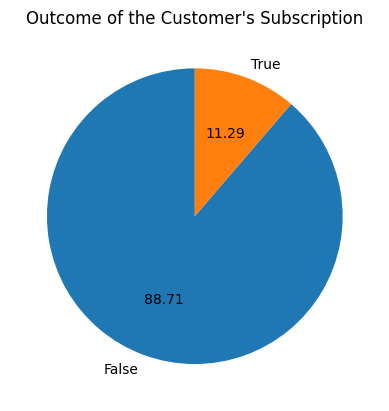

In [ ]:
df["outcome"].value_counts().plot(kind = "pie", startangle = 90, autopct = "%1.2f")
plt.title("Outcome of the Customer's Subscription")
plt.ylabel("")
plt.show()

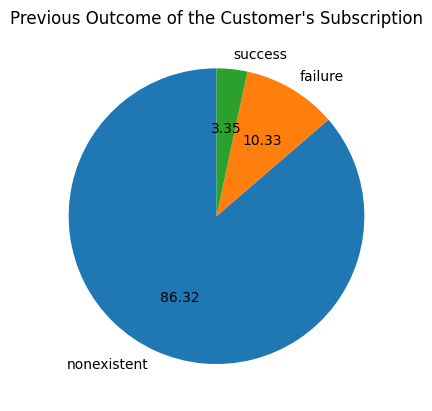

In [ ]:
df["outcome_previous"].value_counts().plot(kind = "pie", startangle = 90, autopct = "%1.2f")
plt.title("Previous Outcome of the Customer's Subscription")
plt.ylabel("")
plt.show()

In [ ]:
df["job"].value_counts()

,count
job,
administrative,8791
industrial,7880
technical,5786
professional,3367
management,2461
retired,1469
entrepreneur,1263
tradesman,1185
domestic,911


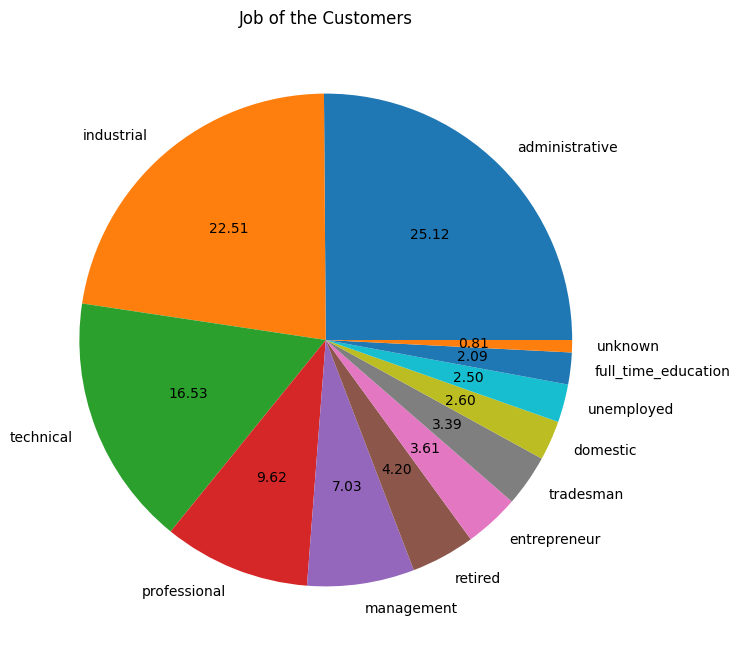

In [ ]:
df["job"].value_counts().plot(kind = "pie", autopct = "%1.2f", figsize = (10, 8))
plt.title("Job of the Customers")
plt.ylabel("")
plt.show()

In [ ]:
df["education"].describe()

,education
count,35000
unique,8
top,university.degree
freq,10319


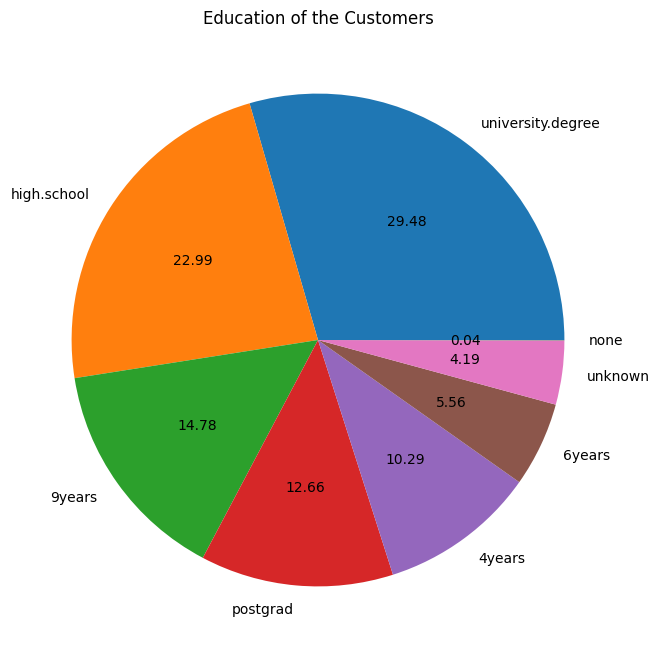

In [ ]:
df["education"].value_counts().plot(kind = "pie", autopct = "%1.2f", figsize = (10, 8))
plt.title("Education of the Customers")
plt.ylabel("")
plt.show()

In [ ]:
# df["num_contacts"].unique()
# df["outcome_previous"].unique()
df["default"].unique()

<StringArray>
['unknown', 'no', 'yes']
Length: 3, dtype: string

In [ ]:
df["default"].value_counts()    # Default is not adding any value to the analysis;
                                # The Marketing was done only towards new clients

,count
default,
no,27653
unknown,7346
yes,1


In [ ]:
df["outcome_previous"].value_counts()

,count
outcome_previous,
nonexistent,30213
failure,3614
success,1173


In [ ]:
df["mortgage"].value_counts()

,count
mortgage,
yes,18304
no,15851
unknown,845


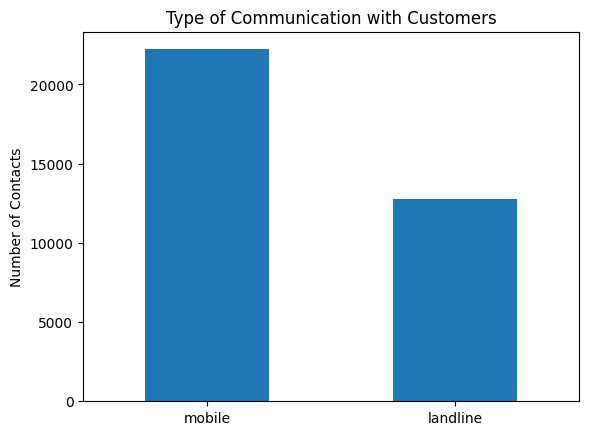

In [ ]:
df["contact"].value_counts().plot(kind = "bar", xlabel = "", ylabel = "Number of Contacts",
                                  title = "Type of Communication with Customers",
                                  rot = 0);

#### Three Main Observations 📝

1. Of 35000 people, only 3952 subscribed. 31048 people declined the offer. This means that only 11.3% of the people subscribed to the classic savings account. Further, there is a variable for the outcome of previous campaigns. However, 86% of the values do not exist, i.e. more than 30,000 values. Hence, the column will be useless for the analysis.

2. The customers work in various areas. Most of them have administrative, industrial or technical jobs.

3. There are two ways to approach the customers - via mobile or via landline. However, nowadays there are more effective ways to advertise your product. There is one question that bothers me. This comes to my mind looking at the advertising campaign: "Who under the blue skies is using a landline phone nowadays?"


## 1. Cleaning the Data

#### Dataset Overview 📊

> The **number of data entries** is 35000. They could be divided into 5 main groups:
>
> * When a contact was made
> * Contact Info
> * Personal Info of the Customer
> * Environmental parameters
> * Macroeconomic Situation

#### Target Value 🎯
> The last column of the data frame is **the outcome of the contact**. It indicates whether the client has purchased the product or not. This column will be the target of the ML model. Furthermore, the outcome column will be the main part for most of the figures.

#### Hypotheses ⁉️
> A few **hypotheses** should be defined at the beginning of the analysis. It is very likely that the economic factors will influence the outcome of the campaign. In real-world scenarios, the economy directly affects the customer's behaviour. In addition, it is very important to review the marketing campaign and estimate how positive it was. The success of each type of contact should be compared. Lastly, there is a big possibility that the personal status of each customer (age, job, mortgage, marital status, etc) has a key role in the success of the marketing.

#### Day & Month 📅
> There are two very interesting columns for the *month and the day when the contact with the customer was made*. One of the most important analyses will be the outcome of the campaign based on day and month.

In [ ]:
df_tr = df.copy()

In [ ]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   contact_id             35000 non-null  Int64  
 1   month                  35000 non-null  string 
 2   day_of_week            35000 non-null  string 
 3   contact                35000 non-null  string 
 4   num_contacts           35000 non-null  Int64  
 5   days_since_previous    35000 non-null  Int64  
 6   num_contacts_previous  35000 non-null  Int64  
 7   outcome_previous       35000 non-null  string 
 8   age                    35000 non-null  Int64  
 9   marital                35000 non-null  string 
 10  job                    35000 non-null  string 
 11  education              35000 non-null  string 
 12  default                35000 non-null  string 
 13  mortgage               35000 non-null  string 
 14  personal_loan          35000 non-null  string 
 15  ca

In [ ]:
df_tr.loc[df_tr.isna().any(axis = "columns")].count()

,0
contact_id,0
month,0
day_of_week,0
contact,0
num_contacts,0
days_since_previous,0
num_contacts_previous,0
outcome_previous,0
age,0
marital,0


In [ ]:
df_tr[df_tr.duplicated() == True]

,contact_id,month,day_of_week,contact,num_contacts,days_since_previous,num_contacts_previous,outcome_previous,age,marital,job,education,default,mortgage,personal_loan,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,outcome


In [ ]:
df_tr.head()

,contact_id,month,day_of_week,contact,num_contacts,days_since_previous,num_contacts_previous,outcome_previous,age,marital,job,education,default,mortgage,personal_loan,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,outcome
0,32670,may,mon,mobile,2,-1,1,failure,51,married,industrial,4years,unknown,no,no,0.203883,28,13,1.299,23669.51229,-44.814,255.45575,-1.60866,False
1,8646,jun,wed,landline,5,-1,0,nonexistent,51,married,unemployed,4years,no,no,yes,0.779718,27,21,4.864,24268.31739,-40.546,259.77875,1.25118,False
2,6298,may,tue,landline,3,-1,0,nonexistent,43,married,industrial,4years,unknown,no,no,1.06944,23,14,4.857,24096.1029,-35.308,258.4835,0.98307,False
3,40424,aug,fri,mobile,2,-1,0,nonexistent,27,single,administrative,university.degree,no,yes,no,0.668203,25,25,0.905,23170.50804,-37.151,258.57425,-1.51929,True
4,26659,nov,thu,mobile,1,-1,0,nonexistent,36,single,professional,high.school,no,no,no,5.788102,16,8,4.076,24118.38402,-40.74,256.3,-0.08937,False


In [ ]:
df_tr.loc[:, "call_centre_volume":"outcome"].describe()

,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation
count,35000.0,35000.0,35000.0,35000.0,35000.0,35000.0,35000.0,35000.0
mean,1.195369,25.249143,15.302943,3.617447,23983.917129,-39.285856,257.331209,0.069716
std,1.096587,4.593388,4.972702,1.735458,335.606521,4.492684,1.591324,1.404177
min,0.000188,10.0,2.0,0.634,23040.53484,-49.276,253.55275,-3.03858
25%,0.408458,22.0,11.0,1.344,23669.51229,-41.419,255.95625,-1.60866
50%,0.88596,25.0,14.0,4.857,24096.1029,-40.546,257.80975,0.98307
75%,1.65238,28.0,20.0,4.961,24268.31739,-35.308,258.4835,1.25118
max,12.263099,42.0,29.0,5.045,24268.31739,-26.093,260.60925,1.25118


In [ ]:
df_tr["forward_rate"].median()

np.float64(4.857)

In [ ]:
# Store the file after the data cleaning
#df_tr.to_csv("LittleBank_Case_Study_Cleaned.csv", index=False)

## 2. Macroeconomic and Enviromental Factors Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#df = pd.read_csv("/content/data/LittleBank_Case_Study.csv").convert_dtypes()

In [ ]:
# pd.set_option('display.max_columns', None)
# df

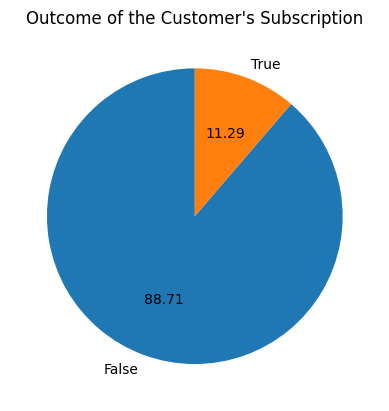

In [ ]:
df["outcome"].value_counts().plot(kind = "pie", startangle = 90, autopct = "%1.2f")
plt.title("Outcome of the Customer's Subscription")
plt.ylabel("")
plt.show()

In [ ]:
df_tr = df.copy()

In [ ]:
months_unique = df_tr.month.unique()
days_unique = df_tr.day_of_week.unique()
months_unique, days_unique

(<StringArray>
 ['may', 'jun', 'aug', 'nov', 'jul', 'sep', 'apr', 'oct', 'mar', 'dec']
 Length: 10, dtype: string,
 <StringArray>
 ['mon', 'wed', 'tue', 'fri', 'thu']
 Length: 5, dtype: string)

In [ ]:
days_of_the_week = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
months_in_the_year = ["jan", "feb", "mar", "apr", "may", "jun",
                      "jul", "aug","sep", "oct", "nov", "dec"]

# A dictionary that maps the day with the corresponding number of the day in a week
days_of_the_week_dict = {day:i for i, day in enumerate(days_of_the_week, start = 1)}

# A dictionary that maps the month with the corresponding number of the month in the year
months_in_the_year_dict = {month_str:i for i, month_str in enumerate(months_in_the_year, start = 1)}

In [ ]:
#df_tr['month'].map(months_in_the_year_dict)

In [ ]:
# Insert a new column in the data frame that maps the months with the corresponding number
df_tr.insert(loc = 2, column = "month_no", value = df_tr['month'].map(months_in_the_year_dict))
#df_tr.insert(loc = 4, column = "day_of_week_no", value = df_tr['day_of_week'].map(days_of_the_week_dict))

In [ ]:
df_tr.sort_values(by = "month_no", inplace = True)
df_tr

,contact_id,month,month_no,day_of_week,contact,num_contacts,days_since_previous,num_contacts_previous,outcome_previous,age,marital,job,education,default,mortgage,personal_loan,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,outcome
19009,27759,mar,3,fri,mobile,1,-1,0,nonexistent,34,single,technical,postgrad,no,no,no,1.790112,17,6,1.726,23669.51229,-48.5,255.31825,-1.60866,True
32668,39363,mar,3,fri,mobile,1,-1,0,nonexistent,57,married,industrial,9years,no,no,no,0.021393,15,6,0.636,23249.88453,-33.756,256.76475,-1.60866,False
16002,39148,mar,3,tue,mobile,2,-1,1,failure,31,divorced,administrative,postgrad,no,yes,no,1.117295,19,7,0.655,23249.88453,-33.756,256.76475,-1.60866,True
15999,39178,mar,3,thu,mobile,3,-1,1,failure,34,married,administrative,postgrad,no,yes,no,1.14374,17,6,0.654,23249.88453,-33.756,256.76475,-1.60866,True
557,27834,mar,3,fri,mobile,1,-1,0,nonexistent,37,single,unemployed,university.degree,no,yes,no,0.48888,15,5,1.64,23669.51229,-48.5,255.31825,-1.60866,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20973,39053,dec,12,thu,mobile,1,-1,1,failure,47,married,domestic,9years,no,yes,no,1.842931,13,4,0.712,23318.58465,-32.01,254.96075,-2.6811,False
20204,39063,dec,12,fri,mobile,4,6,1,success,38,single,unemployed,high.school,no,yes,no,0.596272,16,4,0.71,23318.58465,-32.01,254.96075,-2.6811,True
10936,38980,dec,12,fri,mobile,2,-1,0,nonexistent,60,married,retired,university.degree,no,yes,no,0.364568,13,4,0.718,23318.58465,-32.01,254.96075,-2.6811,False
27974,39004,dec,12,wed,mobile,1,6,1,success,42,married,professional,university.degree,no,no,no,0.344122,16,4,0.715,23318.58465,-32.01,254.96075,-2.6811,True


In [ ]:
## Insert a new column in the data frame that maps the days with the corresponding number
#df_tr.insert(loc = 3, column = "day_no", value = df_tr["day_of_week"].map(days_of_the_week_dict))

In [ ]:
## Drop the new Column if necessary
#df_tr.drop(labels = "month_no", axis = 1, inplace = True)
#df_tr

In [ ]:
df_outcome_true = df_tr[df_tr["outcome"] == "True"]
df_outcome_false = df_tr[df_tr["outcome"] == "False"]

In [ ]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 19009 to 12602
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   contact_id             35000 non-null  Int64  
 1   month                  35000 non-null  string 
 2   month_no               35000 non-null  int64  
 3   day_of_week            35000 non-null  string 
 4   contact                35000 non-null  string 
 5   num_contacts           35000 non-null  Int64  
 6   days_since_previous    35000 non-null  Int64  
 7   num_contacts_previous  35000 non-null  Int64  
 8   outcome_previous       35000 non-null  string 
 9   age                    35000 non-null  Int64  
 10  marital                35000 non-null  string 
 11  job                    35000 non-null  string 
 12  education              35000 non-null  string 
 13  default                35000 non-null  string 
 14  mortgage               35000 non-null  string 
 15  per

In [ ]:
columns = [df_tr.columns[0]] + list(df_tr.columns[18:])   #24 with drop /25 with no drop
df_economy = df_tr[columns]

In [ ]:
df_economy.describe()

,contact_id,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation
count,35000.0,35000.0,35000.0,35000.0,35000.0,35000.0,35000.0
mean,20613.104229,15.302943,3.617447,23983.917129,-39.285856,257.331209,0.069716
std,11910.710552,4.972702,1.735458,335.606521,4.492684,1.591324,1.404177
min,0.0,2.0,0.634,23040.53484,-49.276,253.55275,-3.03858
25%,10274.75,11.0,1.344,23669.51229,-41.419,255.95625,-1.60866
50%,20667.5,14.0,4.857,24096.1029,-40.546,257.80975,0.98307
75%,30926.5,20.0,4.961,24268.31739,-35.308,258.4835,1.25118
max,41187.0,29.0,5.045,24268.31739,-26.093,260.60925,1.25118


In [ ]:
# There is a higher probability that num_employed and price_index do not influence the results
# forward_rate, consumer_confidence and employment_variation have the highest fluctuations

In [ ]:
df_economy[df_economy["outcome"] == "True"].describe()

,contact_id,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation
count,3952.0,3952.0,3952.0,3952.0,3952.0,3952.0,3952.0
mean,30438.638411,14.767713,2.114,23648.410908,-38.534355,256.720247,-1.109934
std,10783.544335,5.504439,1.742297,406.362194,5.976964,1.868466,1.451499
min,75.0,3.0,0.634,23040.53484,-49.276,253.55275,-3.03858
25%,24100.75,10.0,0.849,23290.73325,-44.814,255.45575,-1.60866
50%,35833.0,15.0,1.266,23669.51229,-39.091,256.3,-1.60866
75%,38965.5,20.0,4.343,24096.1029,-35.017,258.2745,-0.08937
max,41186.0,27.0,5.045,24268.31739,-26.093,260.60925,1.25118


In [ ]:
df_economy[df_economy["outcome"] == "False"].describe()

,contact_id,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation
count,31048.0,31048.0,31048.0,31048.0,31048.0,31048.0,31048.0
mean,19362.443603,15.371071,3.808816,24026.622636,-39.381513,257.408976,0.21987
std,11457.394567,4.896783,1.638456,299.670206,4.257492,1.53519,1.324726
min,0.0,2.0,0.634,23040.53484,-49.276,253.55275,-3.03858
25%,9425.75,12.0,1.405,23669.51229,-41.419,255.95625,-1.60866
50%,19162.5,14.0,4.857,24118.38402,-40.546,258.2745,0.98307
75%,29036.25,20.0,4.962,24268.31739,-35.308,258.4835,1.25118
max,41187.0,29.0,5.045,24268.31739,-26.093,260.60925,1.25118


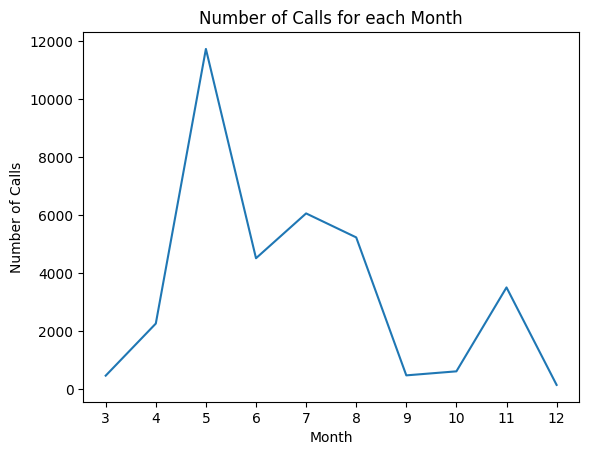

In [ ]:
plt.plot(df_tr["month_no"].unique(), df_tr["month_no"].value_counts(sort = False));

plt.title("Number of Calls for each Month")
plt.xlabel("Month")
plt.ylabel("Number of Calls")
plt.xticks(df_tr["month_no"].unique())
plt.show()

In [ ]:
df_economy_mean = df_tr.groupby("month_no")[["forward_rate", "num_employed",
                                               "consumer_confidence", "price_index",
                                               "employment_variation"]].agg("mean")     # median
df_economy_mean

,forward_rate,num_employed,consumer_confidence,price_index,employment_variation
month_no,,,,,
3,1.156312,23463.284972,-41.254017,256.029137,-1.60866
4,1.357847,23640.015909,-44.834712,256.086536,-1.60866
5,3.299543,23904.332629,-39.346696,257.209168,-0.143087
6,4.23932,24122.540743,-40.326503,259.158698,0.598375
7,4.687485,24203.5264,-41.103638,258.213246,1.037583
8,4.299772,24139.529605,-34.517923,256.596918,0.665371
9,0.834952,23156.735775,-32.906134,256.722752,-1.937721
10,1.211686,23297.290592,-33.705063,256.275976,-2.160234
11,3.719921,24011.745798,-40.005433,256.305409,-0.375242


In [ ]:
df_economy_mean_true = df_outcome_true.groupby("month_no")[["forward_rate", "num_employed",
                                               "consumer_confidence", "price_index",
                                               "employment_variation"]].agg("mean")
df_economy_mean_false = df_outcome_false.groupby("month_no")[["forward_rate", "num_employed",
                                               "consumer_confidence", "price_index",
                                               "employment_variation"]].agg("mean")

In [ ]:
months_x_axis = df_tr["month_no"].unique()
months_x_axis

array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

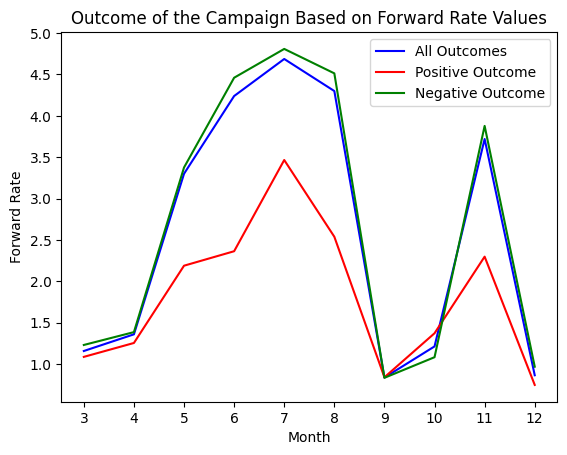

In [ ]:
plt.plot(months_x_axis, df_economy_mean["forward_rate"], "b", label = "All Outcomes")
plt.plot(months_x_axis, df_economy_mean_true["forward_rate"], "r", label = "Positive Outcome")
plt.plot(months_x_axis, df_economy_mean_false["forward_rate"], "g", label = "Negative Outcome")

plt.title("Outcome of the Campaign Based on Forward Rate Values")
plt.xlabel("Month")
plt.ylabel("Forward Rate")
plt.xticks(months_x_axis)
plt.legend()
plt.show()

In [ ]:
# There is a higher probability that num_employed and price_index do not influence the results
# forward_rate, consumer_confidence and employment_variation have the highest fluctuations

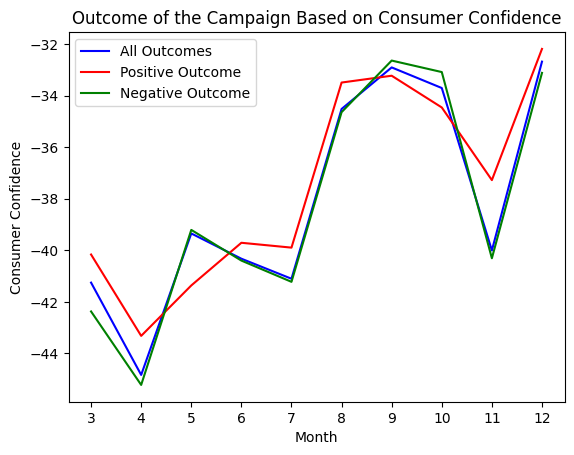

In [ ]:
plt.plot(months_x_axis, df_economy_mean["consumer_confidence"], "b", label = "All Outcomes")
plt.plot(months_x_axis, df_economy_mean_true["consumer_confidence"], "r", label = "Positive Outcome")
plt.plot(months_x_axis, df_economy_mean_false["consumer_confidence"], "g", label = "Negative Outcome")

plt.title("Outcome of the Campaign Based on Consumer Confidence")
plt.xlabel("Month")
plt.ylabel("Consumer Confidence")
plt.xticks(months_x_axis)
plt.legend()
plt.show()

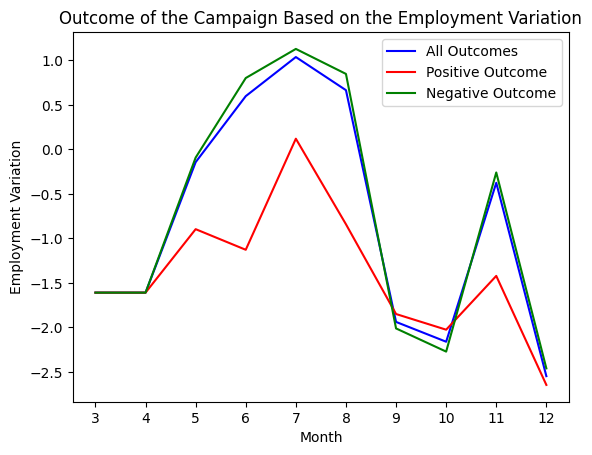

In [ ]:
plt.plot(months_x_axis, df_economy_mean["employment_variation"], "b", label = "All Outcomes")
plt.plot(months_x_axis, df_economy_mean_true["employment_variation"], "r", label = "Positive Outcome")
plt.plot(months_x_axis, df_economy_mean_false["employment_variation"], "g", label = "Negative Outcome")

plt.title("Outcome of the Campaign Based on the Employment Variation")
plt.xlabel("Month")
plt.ylabel("Employment Variation")
plt.xticks(months_x_axis)
plt.legend()
plt.show()

Economy Parameters that aren't supposed to influence highly the outcome of the marketing

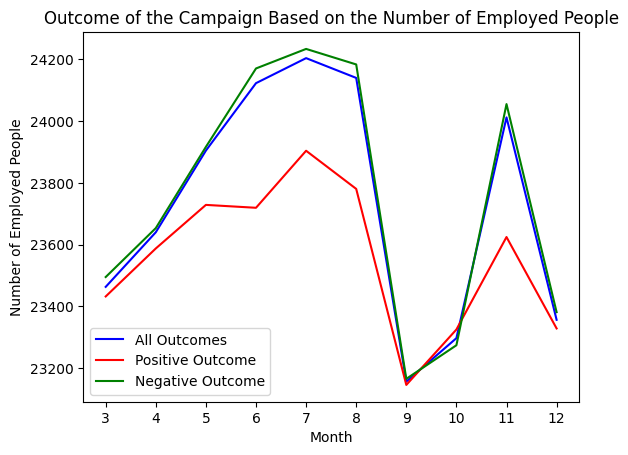

In [ ]:
plt.plot(months_x_axis, df_economy_mean["num_employed"], "b", label = "All Outcomes")
plt.plot(months_x_axis, df_economy_mean_true["num_employed"], "r", label = "Positive Outcome")
plt.plot(months_x_axis, df_economy_mean_false["num_employed"], "g", label = "Negative Outcome")

plt.title("Outcome of the Campaign Based on the Number of Employed People")
plt.xlabel("Month")
plt.ylabel("Number of Employed People")
plt.xticks(months_x_axis)
plt.legend()
plt.show()

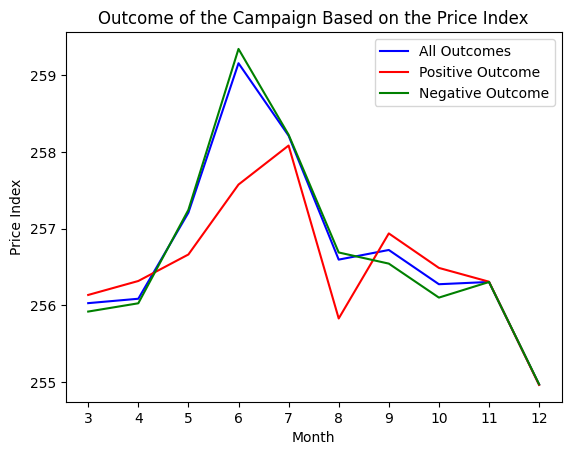

In [ ]:
plt.plot(months_x_axis, df_economy_mean["price_index"], "b", label = "All Outcomes")
plt.plot(months_x_axis, df_economy_mean_true["price_index"], "r", label = "Positive Outcome")
plt.plot(months_x_axis, df_economy_mean_false["price_index"], "g", label = "Negative Outcome")

plt.title("Outcome of the Campaign Based on the Price Index")
plt.xlabel("Month")
plt.ylabel("Price Index")
plt.xticks(months_x_axis)
plt.legend()
plt.show()

> The figures are not quite informative. Most of the section will be deleted in the final solution.

## 3. Analyze the Influence of Day and Months Over the Outcome

This is the most important analysis. It should be done first. Don't forget that in data science tasks, the main goals are to understand the data and make the right conclusions.

In [ ]:
df_outcome_pivot = df_tr.pivot_table(index = "month",
                                     columns = "outcome",
                                     aggfunc = "size",
                                     sort = False)
df_outcome_pivot["Total"] = df_outcome_pivot.iloc[:, 0] + df_outcome_pivot.iloc[:, 1]
df_outcome_pivot["Successful_Rate"] = (df_outcome_pivot.iloc[:, 0] / df_outcome_pivot.iloc[:, 2]) * 100

df_outcome_pivot
# Total Column, Percent of Successful Outcomes
# Day and Months Connected To the Successfull Outcome

outcome,True,False,Total,Successful_Rate
month,,,,
mar,237,231,468,50.641026
apr,461,1801,2262,20.380195
may,749,10972,11721,6.390240
jun,476,4036,4512,10.549645
jul,548,5508,6056,9.048877
aug,566,4664,5230,10.822180
sep,216,262,478,45.188285
oct,278,339,617,45.056726
nov,351,3156,3507,10.008554


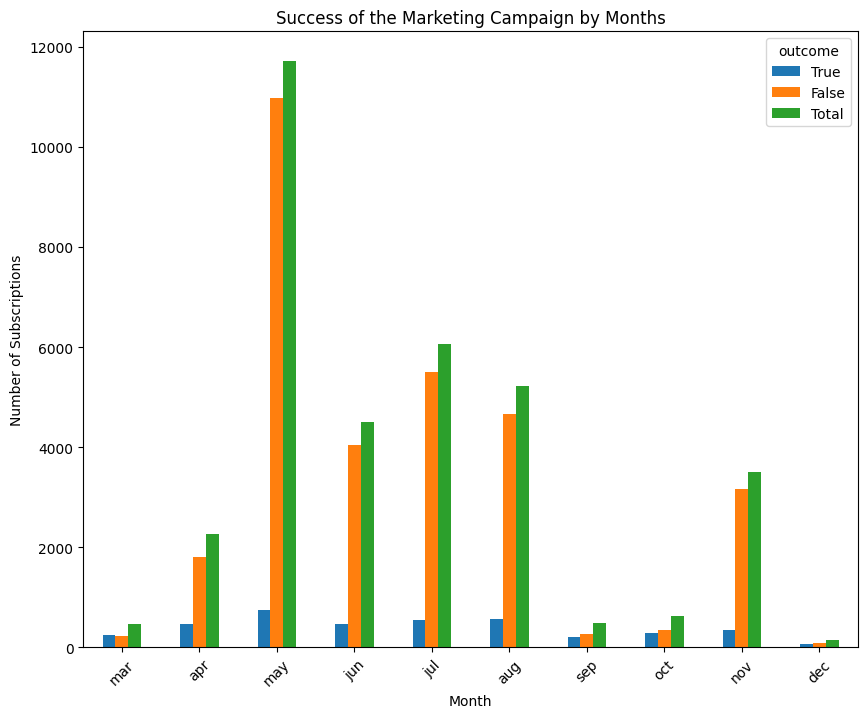

In [ ]:
df_outcome_pivot.iloc[:, 0:3].plot(kind = "bar", figsize = (10, 8), rot = 45)

plt.xlabel("Month")
plt.ylabel("Number of Subscriptions")
plt.title("Success of the Marketing Campaign by Months")
plt.show()

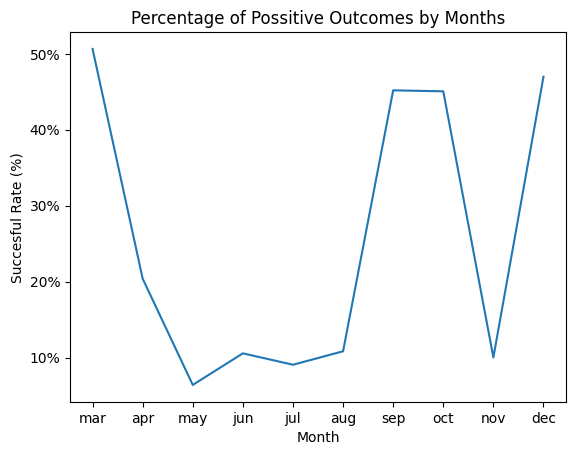

In [ ]:
df_outcome_pivot.iloc[:, 3].plot(kind = "line")

label_month = df_outcome_pivot.index
index_month = range(len(label_month))

plt.xlabel("Month")
plt.xticks(index_month, label_month)
plt.ylabel("Succesful Rate (%)")
plt.title("Percentage of Possitive Outcomes by Months")

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}%"))

Days...

In [ ]:
df_tr.insert(loc = 4, column = "day_of_week_no", value = df_tr['day_of_week'].map(days_of_the_week_dict))

In [ ]:
df_tr.sort_values(by = ["month_no", "day_of_week_no"], inplace = True)
df_tr

,contact_id,month,month_no,day_of_week,day_of_week_no,contact,num_contacts,days_since_previous,num_contacts_previous,outcome_previous,age,marital,job,education,default,mortgage,personal_loan,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,outcome
15803,39275,mar,3,mon,1,landline,2,-1,0,nonexistent,82,married,retired,postgrad,no,yes,no,2.166967,14,7,0.646,23249.88453,-33.756,256.76475,-1.60866,True
21505,27696,mar,3,mon,1,mobile,2,-1,0,nonexistent,28,single,technical,university.degree,no,yes,no,0.063065,15,7,1.811,23669.51229,-48.5,255.31825,-1.60866,False
21731,39276,mar,3,mon,1,mobile,2,-1,0,nonexistent,29,single,administrative,university.degree,no,no,no,0.790375,16,6,0.646,23249.88453,-33.756,256.76475,-1.60866,False
32260,39198,mar,3,mon,1,mobile,2,9,1,success,43,married,tradesman,university.degree,no,yes,no,0.051659,18,6,0.652,23249.88453,-33.756,256.76475,-1.60866,True
3172,39268,mar,3,mon,1,mobile,1,6,1,success,62,married,technical,unknown,no,yes,no,1.456367,16,7,0.646,23249.88453,-33.756,256.76475,-1.60866,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16166,38982,dec,12,fri,5,mobile,2,4,1,success,25,single,administrative,university.degree,no,no,no,3.514996,16,4,0.718,23318.58465,-32.01,254.96075,-2.6811,False
12075,39031,dec,12,fri,5,mobile,2,-1,0,nonexistent,62,married,domestic,postgrad,no,yes,no,1.593702,17,4,0.714,23318.58465,-32.01,254.96075,-2.6811,True
30003,39065,dec,12,fri,5,mobile,3,6,1,success,21,single,full_time_education,university.degree,no,yes,no,0.772964,16,4,0.71,23318.58465,-32.01,254.96075,-2.6811,True
20204,39063,dec,12,fri,5,mobile,4,6,1,success,38,single,unemployed,high.school,no,yes,no,0.596272,16,4,0.71,23318.58465,-32.01,254.96075,-2.6811,True


In [ ]:
df_tr_days = df_tr.groupby(["month", "day_of_week"], sort = False)["outcome"].agg("size")
df_tr_days

month  day_of_week
mar    mon             127
       tue             116
       wed              54
       thu              88
       fri              83
apr    mon             615
       tue             206
       wed             255
       thu             669
       fri             517
may    mon            2238
       tue            2376
       wed            2511
       thu            2145
       fri            2451
jun    mon            1084
       tue             803
       wed             828
       thu             827
       fri             970
jul    mon            1292
       tue            1269
       wed            1240
       thu            1400
       fri             855
aug    mon            1029
       tue            1113
       wed            1037
       thu            1131
       fri             920
sep    mon              78
       tue              98
       wed             106
       thu              99
       fri              97
oct    mon             112
       tue             129
       wed             110
       thu             144
       fri             122
nov    mon             629
       tue             706
       wed             743
       thu             778
       fri             651
dec    mon              44
       tue              21
       wed              28
       thu              38
       fri              18
Name: outcome, dtype: int64

In [ ]:
df_tr_days_pivot = df_tr.pivot_table(index = ["month", "day_of_week"],
                                     columns = "outcome",
                                     aggfunc = "size",
                                     sort = False)
df_tr_days_pivot

outcome            True  False
month day_of_week             
mar   mon            49     78
      tue            71     45
      wed            32     22
      thu            42     46
      fri            43     40
apr   mon            67    548
      tue            66    140
      wed            76    179
      thu           202    467
      fri            50    467
may   mon           157   2081
      tue           122   2254
      wed           166   2345
      thu           139   2006
      fri           165   2286
jun   mon           121    963
      tue           111    692
      wed            96    732
      thu            71    756
      fri            77    893
jul   mon            99   1193
      tue           112   1157
      wed           113   1127
      thu           122   1278
      fri           102    753
aug   mon            92    937
      tue           134    979
      wed           121    916
      thu           114   1017
      fri           105    815
sep   mon            24     54
      tue            51     47
      wed            53     53
      thu            48     51
      fri            40     57
oct   mon            36     76
      tue            58     71
      wed            52     58
      thu            70     74
      fri            62     60
nov   mon            59    570
      tue            78    628
      wed            69    674
      thu            72    706
      fri            73    578
dec   mon            17     27
      tue            11     10
      wed            19      9
      thu            17     21
      fri             6     12

In [ ]:
df_tr_days_pivot["Total"] = df_tr_days_pivot.iloc[:, 0] + df_tr_days_pivot.iloc[:, 1]
df_tr_days_pivot

outcome            True  False  Total
month day_of_week                    
mar   mon            49     78    127
      tue            71     45    116
      wed            32     22     54
      thu            42     46     88
      fri            43     40     83
apr   mon            67    548    615
      tue            66    140    206
      wed            76    179    255
      thu           202    467    669
      fri            50    467    517
may   mon           157   2081   2238
      tue           122   2254   2376
      wed           166   2345   2511
      thu           139   2006   2145
      fri           165   2286   2451
jun   mon           121    963   1084
      tue           111    692    803
      wed            96    732    828
      thu            71    756    827
      fri            77    893    970
jul   mon            99   1193   1292
      tue           112   1157   1269
      wed           113   1127   1240
      thu           122   1278   1400
      fri           102    753    855
aug   mon            92    937   1029
      tue           134    979   1113
      wed           121    916   1037
      thu           114   1017   1131
      fri           105    815    920
sep   mon            24     54     78
      tue            51     47     98
      wed            53     53    106
      thu            48     51     99
      fri            40     57     97
oct   mon            36     76    112
      tue            58     71    129
      wed            52     58    110
      thu            70     74    144
      fri            62     60    122
nov   mon            59    570    629
      tue            78    628    706
      wed            69    674    743
      thu            72    706    778
      fri            73    578    651
dec   mon            17     27     44
      tue            11     10     21
      wed            19      9     28
      thu            17     21     38
      fri             6     12     18

In [ ]:
df_tr_days_pivot.iloc[0:5, :]

outcome            True  False  Total
month day_of_week                    
mar   mon            49     78    127
      tue            71     45    116
      wed            32     22     54
      thu            42     46     88
      fri            43     40     83

In [ ]:
df_tr_days_pivot.iloc[:, 0:3].values

array([[  49,   78,  127],
       [  71,   45,  116],
       [  32,   22,   54],
       [  42,   46,   88],
       [  43,   40,   83],
       [  67,  548,  615],
       [  66,  140,  206],
       [  76,  179,  255],
       [ 202,  467,  669],
       [  50,  467,  517],
       [ 157, 2081, 2238],
       [ 122, 2254, 2376],
       [ 166, 2345, 2511],
       [ 139, 2006, 2145],
       [ 165, 2286, 2451],
       [ 121,  963, 1084],
       [ 111,  692,  803],
       [  96,  732,  828],
       [  71,  756,  827],
       [  77,  893,  970],
       [  99, 1193, 1292],
       [ 112, 1157, 1269],
       [ 113, 1127, 1240],
       [ 122, 1278, 1400],
       [ 102,  753,  855],
       [  92,  937, 1029],
       [ 134,  979, 1113],
       [ 121,  916, 1037],
       [ 114, 1017, 1131],
       [ 105,  815,  920],
       [  24,   54,   78],
       [  51,   47,   98],
       [  53,   53,  106],
       [  48,   51,   99],
       [  40,   57,   97],
       [  36,   76,  112],
       [  58,   71,  129],
 

In [ ]:
#days_of_the_week = ["mon", "tue", "wed", "thu", "fri"]
months_in_the_year_df = ["mar", "apr", "may", "jun",
                      "jul", "aug","sep", "oct", "nov", "dec"]

df_tr_days_pivot.loc["dec"].columns
#df_tr_days_pivot.loc["dec"].plot(kind = "bar")

Index(['True', 'False', 'Total'], dtype='string', name='outcome')

In [ ]:
## View the dataframes
#df_plot

In [ ]:
#pd.set_option('display.max_rows', None)
#pd.reset_option("display.max_rows")

#df_melted

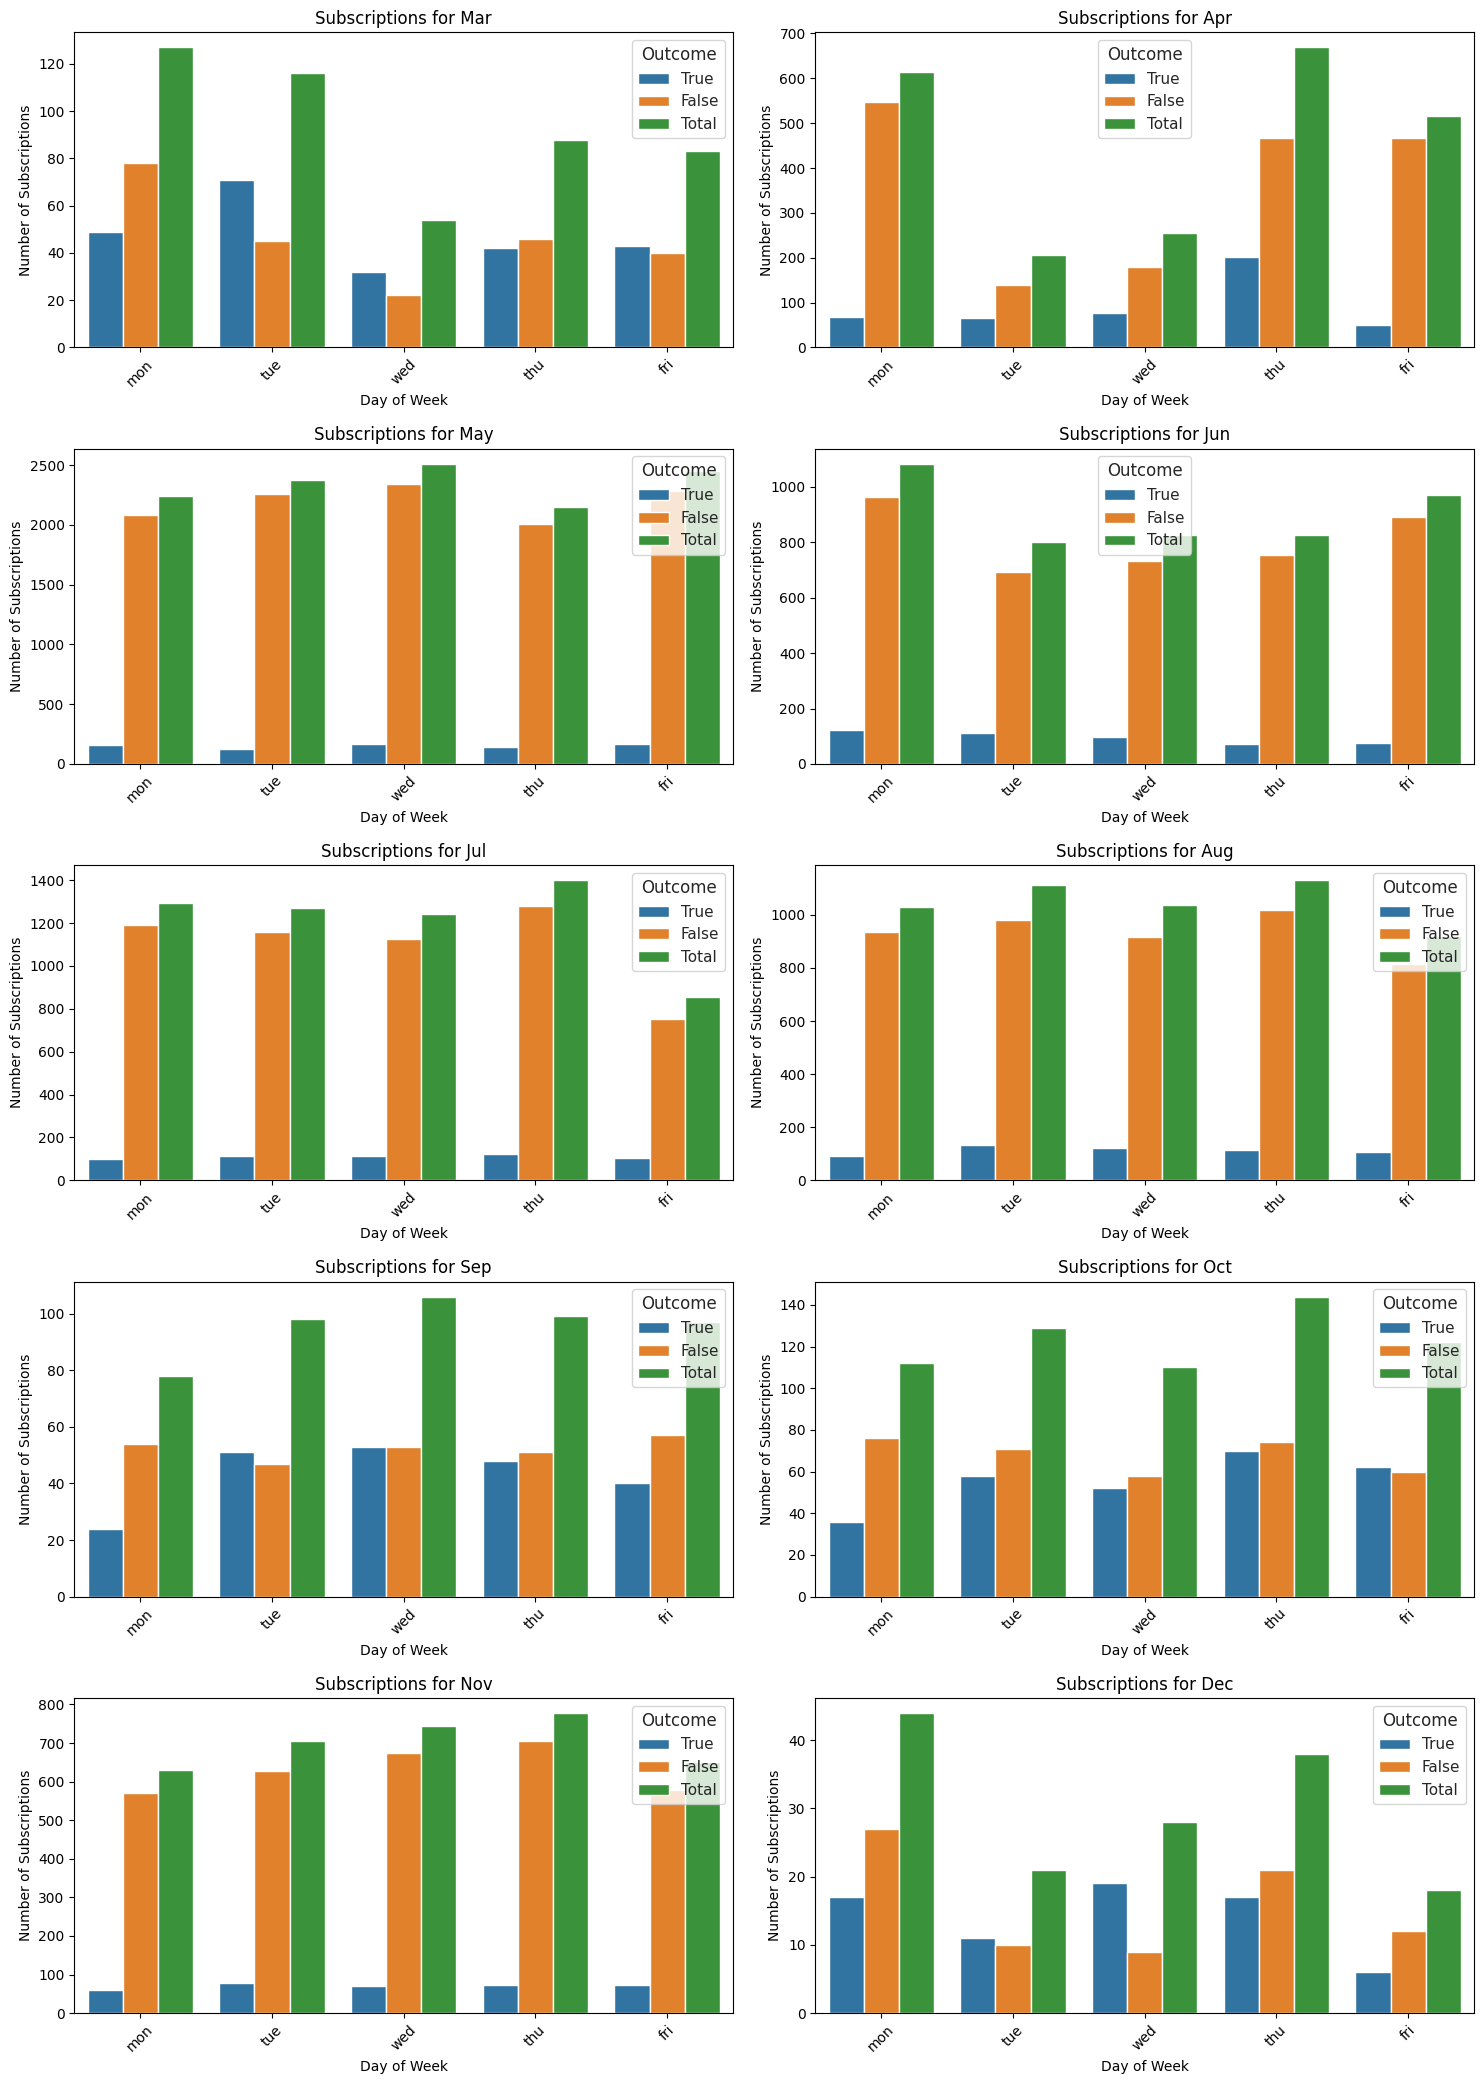

In [ ]:
df_plot = df_tr_days_pivot.reset_index()
df_melted = df_plot.melt(id_vars = ['month', 'day_of_week'],
                         value_vars = ["True", "False", 'Total'],
                         var_name = 'outcome_type',
                         value_name = 'outcome_count')

total_months_df = len(months_in_the_year_df)
rows = int(total_months_df / 2)
cols = 2
y_axis_max_value = df_plot["Total"].max() # Possible scaling 1.05 * df_plot["Total"].max()

fig, ax = plt.subplots(rows, cols, figsize = (15, 21))
sns.set_theme(style = "ticks")
#sns.set_palette("tab10")

for i, month in enumerate(months_in_the_year_df):
    row_idx = i // cols
    col_idx = i % cols
    current_month_df = df_melted[df_melted['month'] == month]

    sns.barplot(data = current_month_df,
                x = 'day_of_week',
                y = 'outcome_count',
                hue = 'outcome_type',
                palette = "tab10",
                ax = ax[row_idx, col_idx])

    ax[row_idx, col_idx].set_title(f"Subscriptions for {month.capitalize()}")
    ax[row_idx, col_idx].set_ylabel("Number of Subscriptions")
    ax[row_idx, col_idx].set_xlabel("Day of Week")
    ax[row_idx, col_idx].tick_params(axis = 'x', rotation = 45)
    ax[row_idx, col_idx].legend(title = 'Outcome')


plt.tight_layout()
plt.show()

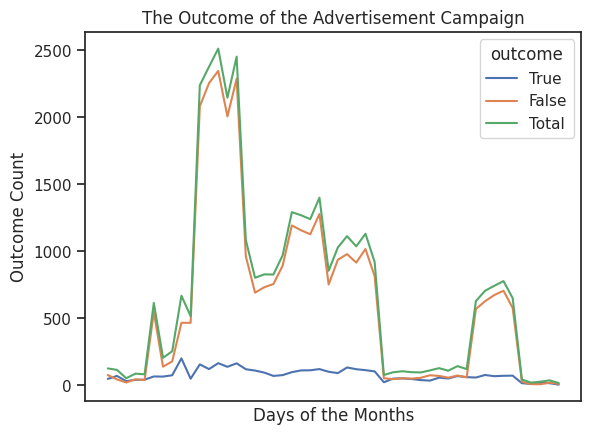

In [ ]:
df_plot.plot(kind = "line",
             title = "The Outcome of the Advertisement Campaign",
             xticks = [],
             xlabel = "Days of the Months",
             ylabel = "Outcome Count");
# The advertisement campaign was a total failure...

😥😥😫

> The marketing campaign was a total failure. The first and the last figures show that the subscriptions do not increase, even though thousands of contacts were made. For May, the savings account product was advertised to 11721 people. Only 749 of them have subscribed. This is exactly 6.39%. That's a disaster.

> When we compare the results of the campaign by days of each month, the conclusion is the same - the marketing was a total failure. There are days when the success rate is above 50%, but a small number of people subscribed in absolute terms. The hypothesis that there is a day in the month when the subscription rate is relatively high could not be accepted.

> Lets compare the positive outcomes with the total number of calls. In March, September, October and December, there is the highest percentage of successful outcomes. In March, more than half of the customers subscribed to the product (50.64%). However, in these months the marketing campaign was not very persuasive.

## 4. Marketing Campaign Analysis

In [ ]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 15803 to 10936
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   contact_id             35000 non-null  Int64  
 1   month                  35000 non-null  string 
 2   month_no               35000 non-null  int64  
 3   day_of_week            35000 non-null  string 
 4   day_of_week_no         35000 non-null  int64  
 5   contact                35000 non-null  string 
 6   num_contacts           35000 non-null  Int64  
 7   days_since_previous    35000 non-null  Int64  
 8   num_contacts_previous  35000 non-null  Int64  
 9   outcome_previous       35000 non-null  string 
 10  age                    35000 non-null  Int64  
 11  marital                35000 non-null  string 
 12  job                    35000 non-null  string 
 13  education              35000 non-null  string 
 14  default                35000 non-null  string 
 15  mor

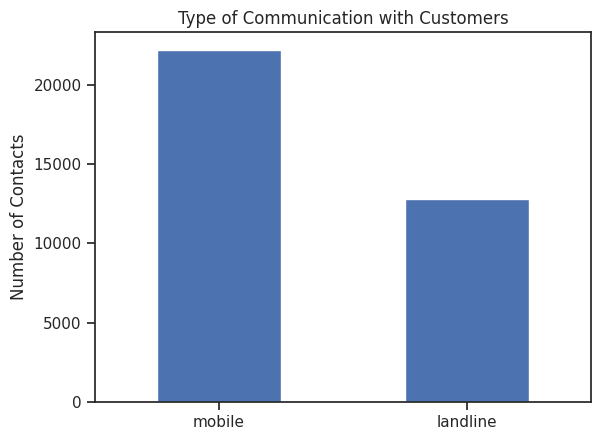

In [ ]:
df["contact"].value_counts().plot(kind = "bar", xlabel = "", ylabel = "Number of Contacts",
                                  title = "Type of Communication with Customers",
                                  rot = 0);

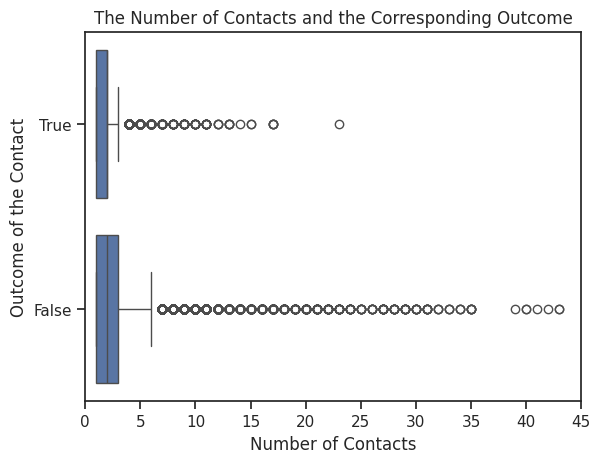

In [ ]:
sns.boxplot(data = df_tr, x = "num_contacts", y = "outcome")
sns.set_theme(style="ticks")

# this is all the same
plt.title("The Number of Contacts and the Corresponding Outcome")
plt.xlabel("Number of Contacts")
plt.ylabel("Outcome of the Contact")

plt.xlim(0, 45)

plt.show()

In [ ]:
df["num_contacts"].sort_values(ascending = False).head(15)  # 30-56 calls for one offer for the same person ???
#df["num_contacts"].sort_values(ascending = False).value_counts(sort = False).head(30) # The Marketing is Total Failure;

# It is very likely that the data is generated by AI; There isn't any logic to make 56 contacts for 1 person for marketing.
# Guess what present you will receive from me when call me for 4th time to promote me your product...

,num_contacts
25009,56
32572,43
15066,43
2248,42
8859,41
12534,40
27689,40
2585,39
26561,35
23403,35


In [ ]:
df_tr.loc[:, "contact":"outcome_previous"].describe()

,num_contacts,days_since_previous,num_contacts_previous
count,35000.0,35000.0,35000.0
mean,2.567514,-0.743171,0.173686
std,2.783935,1.495007,0.498266
min,1.0,-1.0,0.0
25%,1.0,-1.0,0.0
50%,2.0,-1.0,0.0
75%,3.0,-1.0,0.0
max,56.0,27.0,7.0


In [ ]:
df_tr.loc[:, "call_centre_volume"].describe()

,call_centre_volume
count,35000.0
mean,1.195369
std,1.096587
min,0.000188
25%,0.408458
50%,0.88596
75%,1.65238
max,12.263099


In [ ]:
len(df_tr[df_tr["days_since_previous"].values == -1])

33705

In [ ]:
len(df_tr[df_tr["num_contacts_previous"].values == 0])

30213

In [ ]:
df["outcome_previous"].unique()

<StringArray>
['failure', 'nonexistent', 'success']
Length: 3, dtype: string

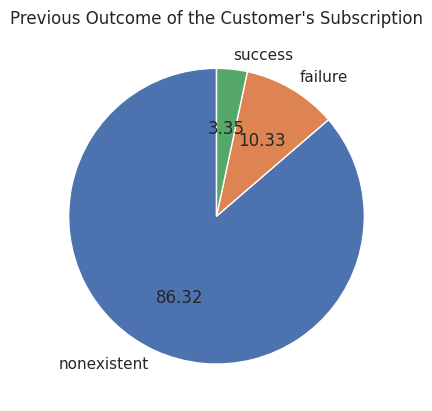

In [ ]:
df["outcome_previous"].value_counts().plot(kind = "pie", startangle = 90, autopct = "%1.2f")
plt.title("Previous Outcome of the Customer's Subscription")
plt.ylabel("")
plt.show()

In [ ]:
# Successful outcome by month (day) for a type of contact

In [ ]:
df_contact = df_tr.pivot_table(index = "contact",
                               columns = "outcome",
                               aggfunc = "size",
                               sort = False)

type_of_contact_subscription = (df_contact.iloc[:, 0] / df_contact.iloc[:, 1]) * 100 # in percentage
type_of_contact_subscription

,0
contact,
landline,5.652425
mobile,17.248113


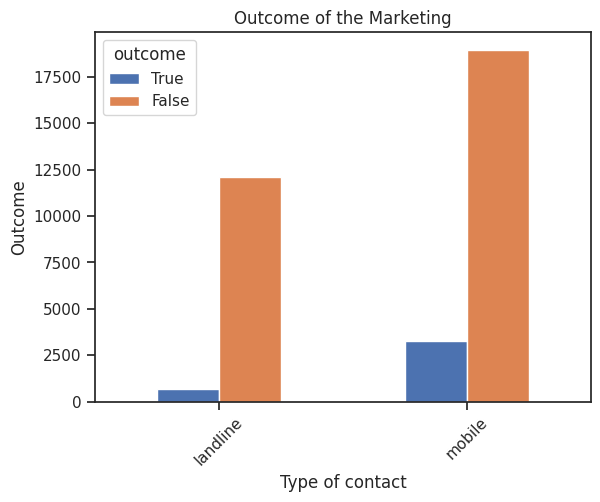

In [ ]:
df_contact.plot(kind = "bar", xlabel = "Type of contact", ylabel = "Outcome",
                title = "Outcome of the Marketing", rot = 45);

In [ ]:
mean_contacts_successful_outcome = df_tr[df_tr["outcome"] == "True"]["num_contacts"].mean()     # 2.045
num_contacts_successful_outcome = df_tr[df_tr["outcome"] == "True"]["num_contacts"].median()    # 2.0

print(f"The average number of contacts for a successful outcome is {int(num_contacts_successful_outcome)}.")

The average number of contacts for a successful outcome is 2.


In [ ]:
df_contact_type_pivot = df_tr.pivot_table(index = ["month", "contact"],
                                          columns = "outcome",
                                          aggfunc = "size",
                                          sort = False)
df_contact_type_pivot["Total"] = df_contact_type_pivot.iloc[:, 0] + df_contact_type_pivot.iloc[:, 1]
df_contact_type_pivot

outcome         True  False  Total
month contact                     
mar   landline    22     33     55
      mobile     215    198    413
apr   landline    40    117    157
      mobile     421   1684   2105
may   landline   234   6804   7038
      mobile     515   4168   4683
jun   landline   175   3626   3801
      mobile     301    410    711
jul   landline    49    861    910
      mobile     499   4647   5146
aug   landline    32    188    220
      mobile     534   4476   5010
sep   landline    18     58     76
      mobile     198    204    402
oct   landline    56     80    136
      mobile     222    259    481
nov   landline    48    316    364
      mobile     303   2840   3143
dec   landline    10     18     28
      mobile      60     61    121

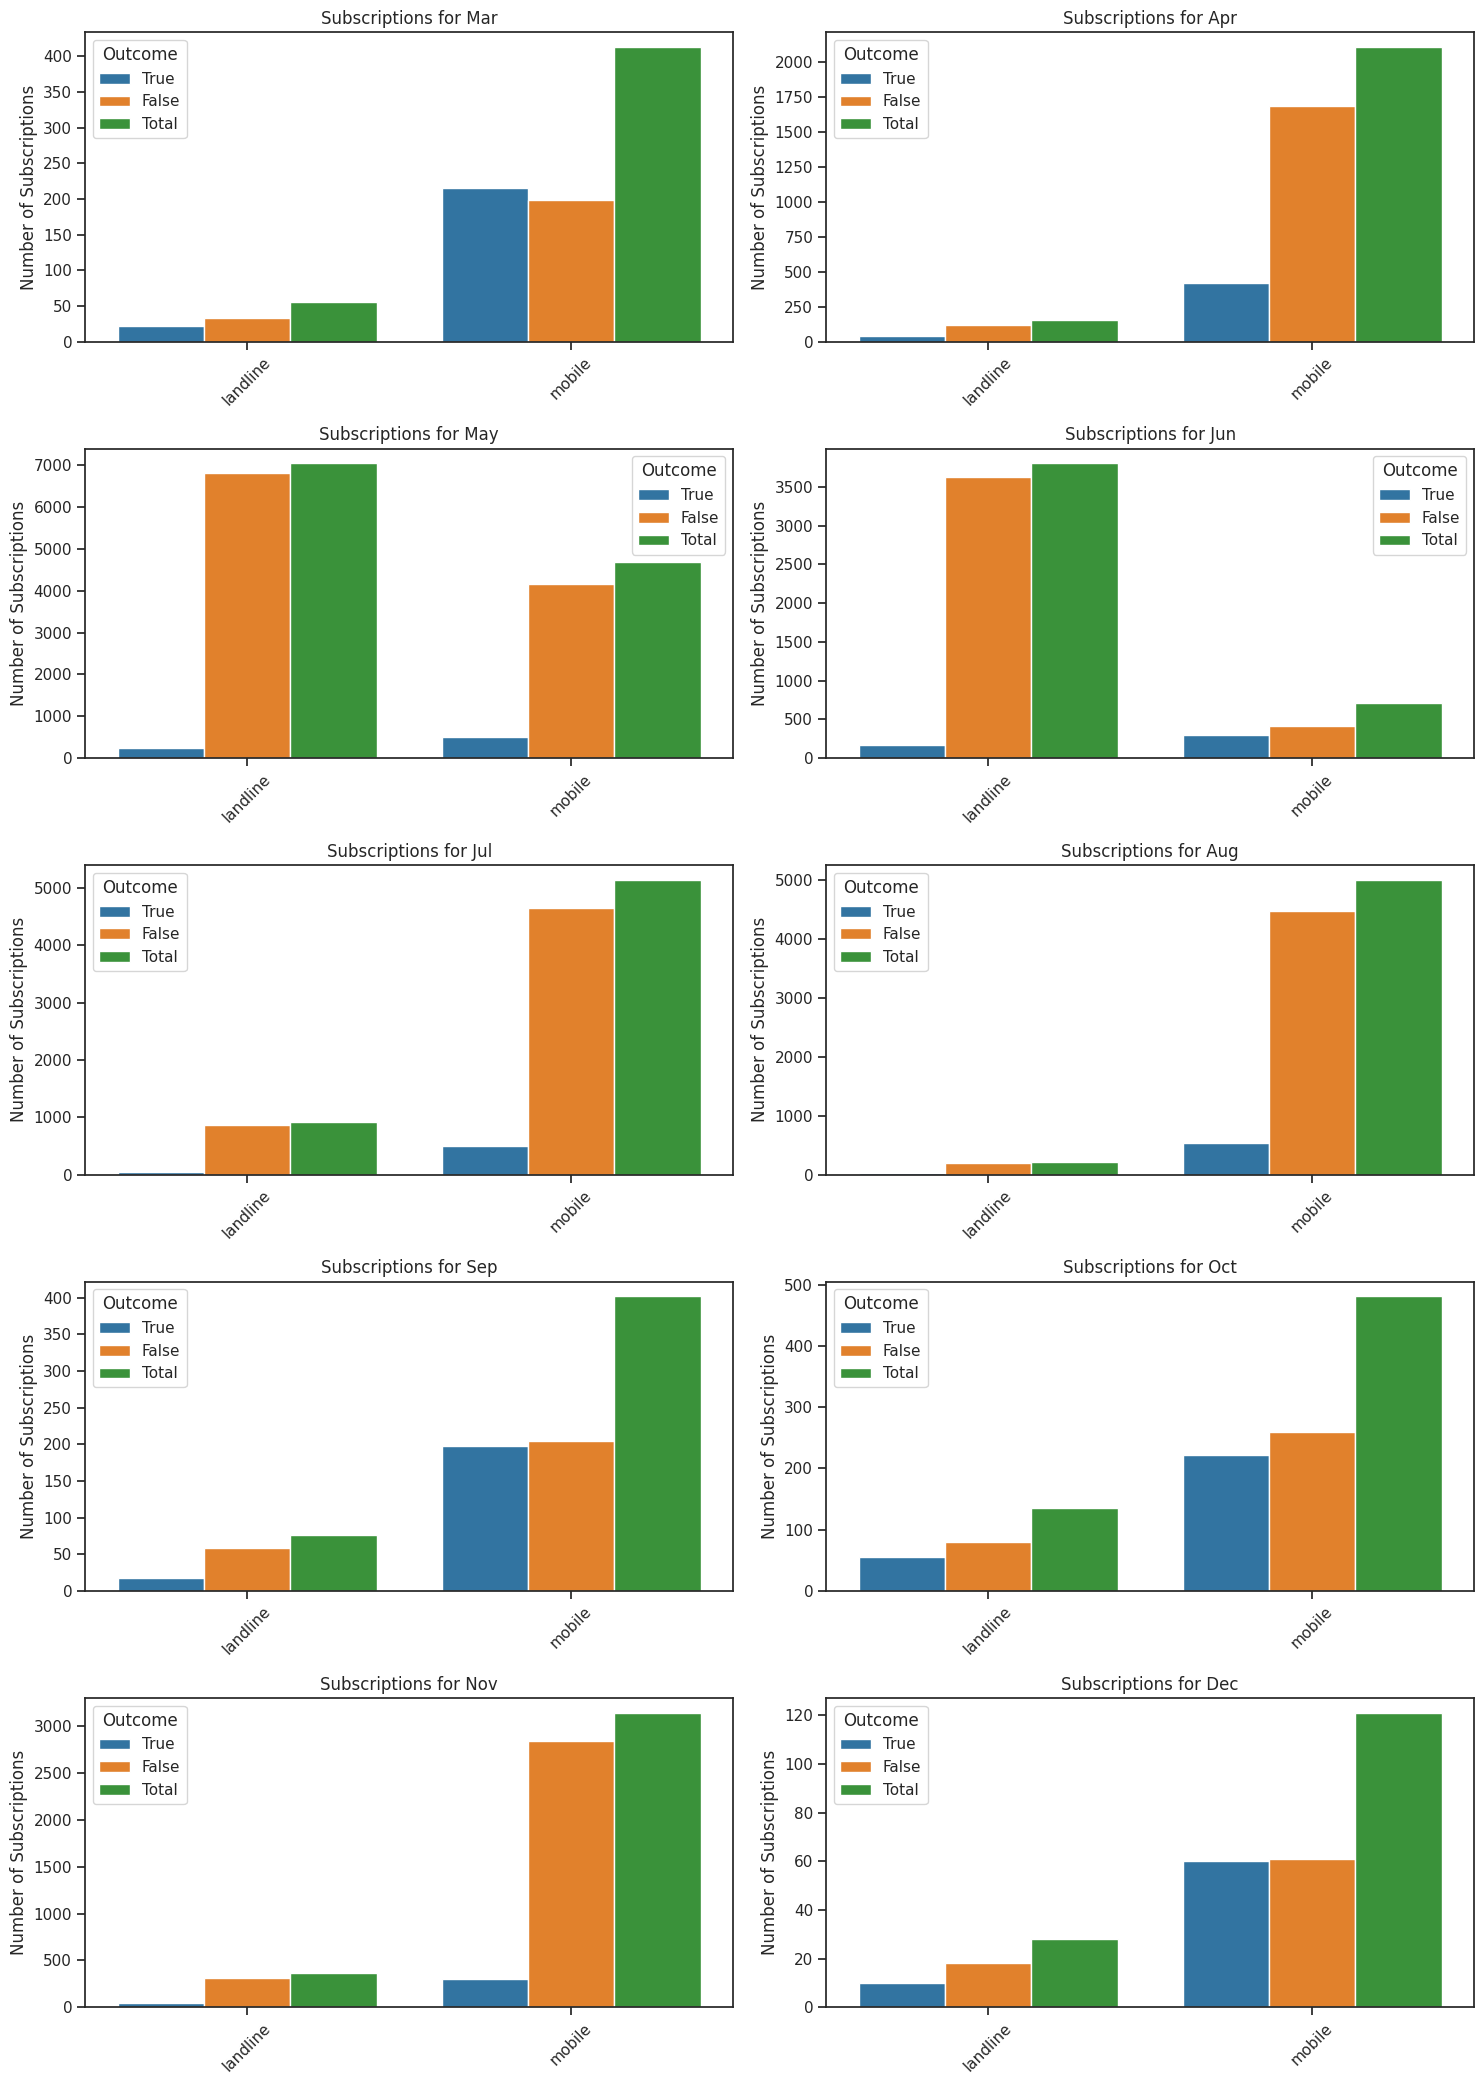

In [ ]:
df_plot_contact = df_contact_type_pivot.reset_index()
df_melted = df_plot_contact.melt(id_vars = ['month', 'contact'],
                                 value_vars = ["True", "False", 'Total'],
                                 var_name = 'outcome_type',
                                 value_name = 'outcome_count')

total_months_df = len(months_in_the_year_df)
rows = int(total_months_df / 2)
cols = 2
y_axis_max_value = df_plot_contact["Total"].max() #+ 1.05 * df_plot["Total"].max()

fig, ax = plt.subplots(rows, cols, figsize = (15, 21))
sns.set_theme(style = "ticks")
#sns.set_palette("tab10")

for i, month in enumerate(months_in_the_year_df):
    row_idx = i // cols
    col_idx = i % cols
    current_month_df = df_melted[df_melted["month"] == month]

    sns.barplot(data = current_month_df,
                x = "contact",
                y = "outcome_count",
                hue = "outcome_type",
                palette = "tab10",
                ax = ax[row_idx, col_idx])

    ax[row_idx, col_idx].set_title(f"Subscriptions for {month.capitalize()}")
    ax[row_idx, col_idx].set_ylabel("Number of Subscriptions")
    ax[row_idx, col_idx].set_xlabel("")
    ax[row_idx, col_idx].tick_params(axis = "x", rotation = 45)
    ax[row_idx, col_idx].legend(title = "Outcome")

plt.tight_layout()
plt.show()

In [ ]:
df_tr["days_since_previous"].value_counts()
df_days_previous = df_tr[(df_tr["days_since_previous"] >= 0) & (df_tr["outcome"] == "True")]
df_days_previous

,contact_id,month,month_no,day_of_week,day_of_week_no,contact,num_contacts,days_since_previous,num_contacts_previous,outcome_previous,age,marital,job,education,default,mortgage,personal_loan,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,outcome
32260,39198,mar,3,mon,1,mobile,2,9,1,success,43,married,tradesman,university.degree,no,yes,no,0.051659,18,6,0.652,23249.88453,-33.756,256.76475,-1.60866,True
3172,39268,mar,3,mon,1,mobile,1,6,1,success,62,married,technical,unknown,no,yes,no,1.456367,16,7,0.646,23249.88453,-33.756,256.76475,-1.60866,True
3939,39262,mar,3,mon,1,mobile,2,3,2,success,62,married,technical,unknown,no,no,no,1.527797,19,6,0.646,23249.88453,-33.756,256.76475,-1.60866,True
5232,39323,mar,3,mon,1,mobile,2,6,2,success,30,unknown,technical,university.degree,no,no,no,0.522963,16,7,0.639,23249.88453,-33.756,256.76475,-1.60866,True
5114,39329,mar,3,mon,1,mobile,1,3,1,success,39,divorced,technical,high.school,no,no,no,2.761982,15,6,0.639,23249.88453,-33.756,256.76475,-1.60866,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7454,39023,dec,12,thu,4,mobile,1,9,2,success,55,married,administrative,postgrad,no,yes,no,0.281687,14,4,0.714,23318.58465,-32.01,254.96075,-2.6811,True
5733,39026,dec,12,thu,4,mobile,1,6,2,success,64,married,domestic,4years,no,no,no,0.783321,13,4,0.714,23318.58465,-32.01,254.96075,-2.6811,True
22300,38967,dec,12,thu,4,mobile,1,4,3,success,83,married,retired,high.school,no,no,no,1.556318,14,4,0.72,23318.58465,-32.01,254.96075,-2.6811,True
30003,39065,dec,12,fri,5,mobile,3,6,1,success,21,single,full_time_education,university.degree,no,yes,no,0.772964,16,4,0.71,23318.58465,-32.01,254.96075,-2.6811,True


In [ ]:
df_days_previous[["days_since_previous", "num_contacts_previous", "call_centre_volume"]].describe()

,days_since_previous,num_contacts_previous,call_centre_volume
count,829.0,829.0,829.0
mean,5.813028,1.716526,1.113276
std,3.606559,0.959559,1.051114
min,0.0,1.0,0.00228
25%,3.0,1.0,0.405312
50%,6.0,1.0,0.809528
75%,6.0,2.0,1.488245
max,27.0,6.0,8.042353


In [ ]:
df_days_previous.groupby("contact")[["days_since_previous", "call_centre_volume", "num_contacts"]].agg(["mean", "median"])

days_since_previous        call_centre_volume           num_contacts  \
                        mean median               mean    median         mean   
contact                                                                         
landline            5.646154    6.0           1.096558  0.863262     1.815385   
mobile              5.827225    6.0           1.114698  0.802669      1.70288   

                 
         median  
contact          
landline    1.0  
mobile      1.0

In [ ]:
df_tr.groupby(["month", "outcome"], sort = False)["call_centre_volume"].agg("median")

month  outcome
mar    True        0.94949
       False      0.724602
apr    False      0.854251
       True       0.940009
may    False      0.884197
       True       0.793895
jun    False      0.896301
       True       0.915008
jul    False      0.888075
       True       0.895634
aug    False      0.894615
       True       0.836781
sep    False       0.83312
       True       0.957726
oct    False      0.829278
       True        0.79458
nov    False      0.919443
       True        0.83942
dec    False      1.041228
       True       0.815637
Name: call_centre_volume, dtype: Float64

#### Overview of the Marketing Campaign 📊
> The classic savings account was advertised through a call. The clients were contacted on mobile (22215 calls) or on their landline (12785 calls). There are strange outliers in the data. There are a few people whom we called 56 times, 43 times, 42 times, etc. If someone dares to think of calling me 56 times to advertise his bloody product, he would receive a warm and energetic blessing after the third call. And that lucky number will be added to my "forever after happy block list" for eternity.

#### Nonexistent Variable ❌
> In addition, most of the values of the days_since_previous column are nonexistent. The same could be said about the outcome_previous column. The mean number of contacts for a successful call is 2.

#### Successful Calls ✅
> The second call for the successful outcome was made around 6 days after the first call. Hence, to increase the chances of success, the second call should be made around 6 days after the first call. In addition,
It is very possible that the volume of the call centre does not affect the success of the call.

#### Marketing in the Digital Era 💬
> As it could be expected, most of the subscriptions came from a mobile device. This is true for each month. Nevertheless, in the digital era where everyone has a profile in more than one social network, there are certainly better ways to connect with your potential customers.





## 5. Analysis Based on the Personal Info of the Customers

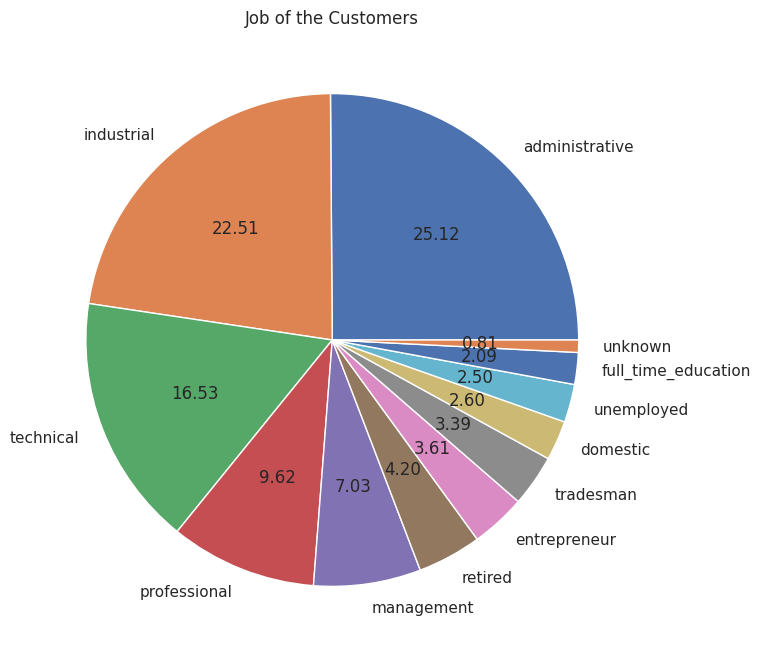

In [ ]:
df["job"].value_counts().plot(kind = "pie", autopct = "%1.2f", figsize = (10, 8))
plt.title("Job of the Customers")
plt.ylabel("")
plt.show()

In [ ]:
df_jobs_pivot = df_tr.pivot_table(index = "job",
                                  columns = "outcome",
                                  aggfunc = "size")

df_jobs_pivot["Total"] = df_jobs_pivot["False"] + df_jobs_pivot["True"]
df_jobs_pivot["Successful_Rate"] = (df_jobs_pivot["True"] / df_jobs_pivot["False"]) * 100
df_jobs_pivot

outcome,False,True,Total,Successful_Rate
job,,,,
administrative,7639,1152,8791,15.080508
domestic,817,94,911,11.505508
entrepreneur,1156,107,1263,9.256055
full_time_education,498,232,730,46.586345
industrial,7337,543,7880,7.400845
management,2186,275,2461,12.580055
professional,3096,271,3367,8.753230
retired,1095,374,1469,34.155251
technical,5156,630,5786,12.218774


In [ ]:
df_jobs_pivot["Successful_Rate"].values

array([15.08050792, 11.50550796,  9.25605536, 46.58634538,  7.40084503,
       12.58005489,  8.75322997, 34.15525114, 12.21877424, 11.68708765,
       15.91511936, 11.85770751])

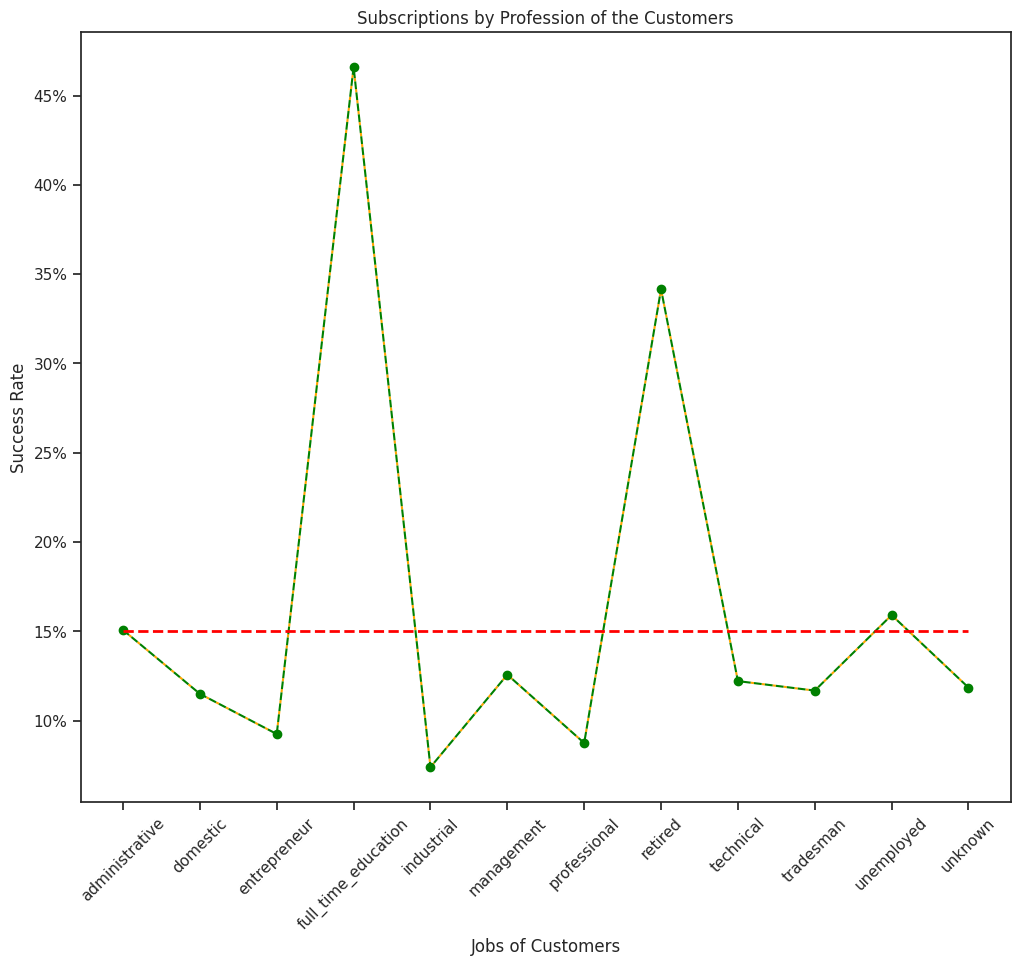

In [ ]:
x = df_jobs_pivot.index
y = df_jobs_pivot["Successful_Rate"].values

y1 = np.ones(len(y)) * 15              # Draw a line for 15%

plt.figure(figsize = (12, 10))
plt.plot(x, y, color = "green", marker = "o", linestyle = "dashed", dash_capstyle = "butt",
         gapcolor = "orange")
plt.plot(x, y1, color = "red", linewidth = 2, linestyle = "dashed")

plt.title("Subscriptions by Profession of the Customers")
plt.xlabel("Jobs of Customers")
plt.xticks(rotation = 45, ha = "center")

plt.ylabel("Success Rate")

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}%"))

plt.show()

In [ ]:
df_jobs_outcome_t = df_tr[df_tr["outcome"] == "True"].pivot_table(values = "outcome",
                                                                  index = "job",
                                                                  columns = "contact",
                                                                  aggfunc = "size")
df_jobs_outcome_f = df_tr[df_tr["outcome"] == "False"].pivot_table(values = "outcome",
                                                                   index = "job",
                                                                   columns = "contact",
                                                                   aggfunc = "size")
df_jobs_outcome = df_tr.pivot_table(values = "outcome",
                                    index = "job",
                                    columns = "contact",
                                    aggfunc = "size")

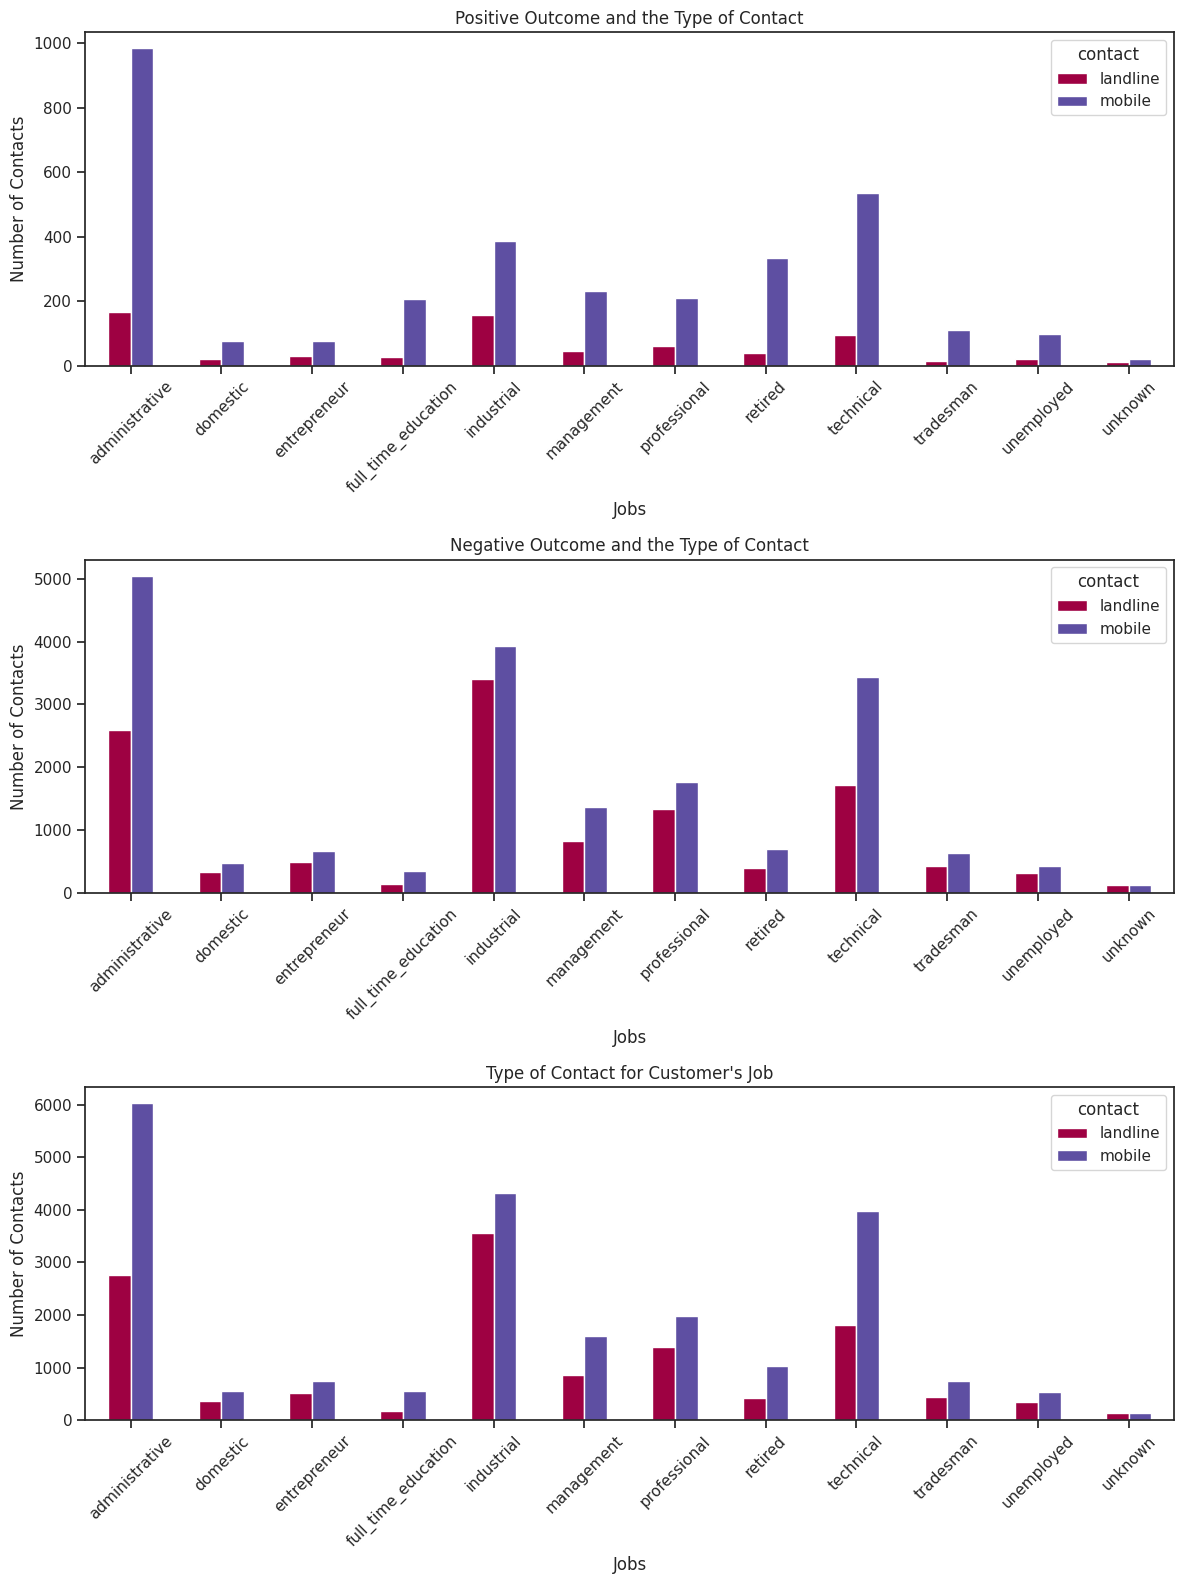

In [ ]:
fig, ax = plt.subplots(3, 1, figsize = (12, 16))

df_jobs_outcome_t.plot(kind = "bar", ax = ax[0], rot = 45,
                       colormap = "Spectral")
ax[0].set_title("Positive Outcome and the Type of Contact")
ax[0].set_xlabel("Jobs")
ax[0].set_ylabel("Number of Contacts")

df_jobs_outcome_f.plot(kind = "bar", ax = ax[1], rot = 45,
                       colormap = "Spectral")
ax[1].set_title("Negative Outcome and the Type of Contact")
ax[1].set_xlabel("Jobs")
ax[1].set_ylabel("Number of Contacts")

df_jobs_outcome.plot(kind = "bar", ax = ax[2], rot = 45,
                     colormap = "Spectral")
ax[2].set_title("Type of Contact for Customer's Job")
ax[2].set_xlabel("Jobs")
ax[2].set_ylabel("Number of Contacts")

fig.tight_layout()

In [ ]:
df_education = df_tr.pivot_table(index = "education",
                                 columns = "outcome",
                                 aggfunc = "size",
                                 sort = False)

In [ ]:
df_education.drop(index="none", inplace=True)

In [ ]:
df_education.sort_values(by = "education", inplace = True)

In [ ]:
df_education

outcome,True,False
education,,
4years,384,3219
6years,159,1787
9years,395,4779
high.school,879,7169
postgrad,504,3927
university.degree,1416,8903
unknown,211,1254


In [ ]:
#df_education = df_education.reset_index()
# df_education_plot = df_education.melt(id_vars = ['education', 'contact'],
#                                       value_vars = ["True", "False"],
#                                       var_name = 'outcome_type',
#                                       value_name = 'outcome_count')
# df_education_plot


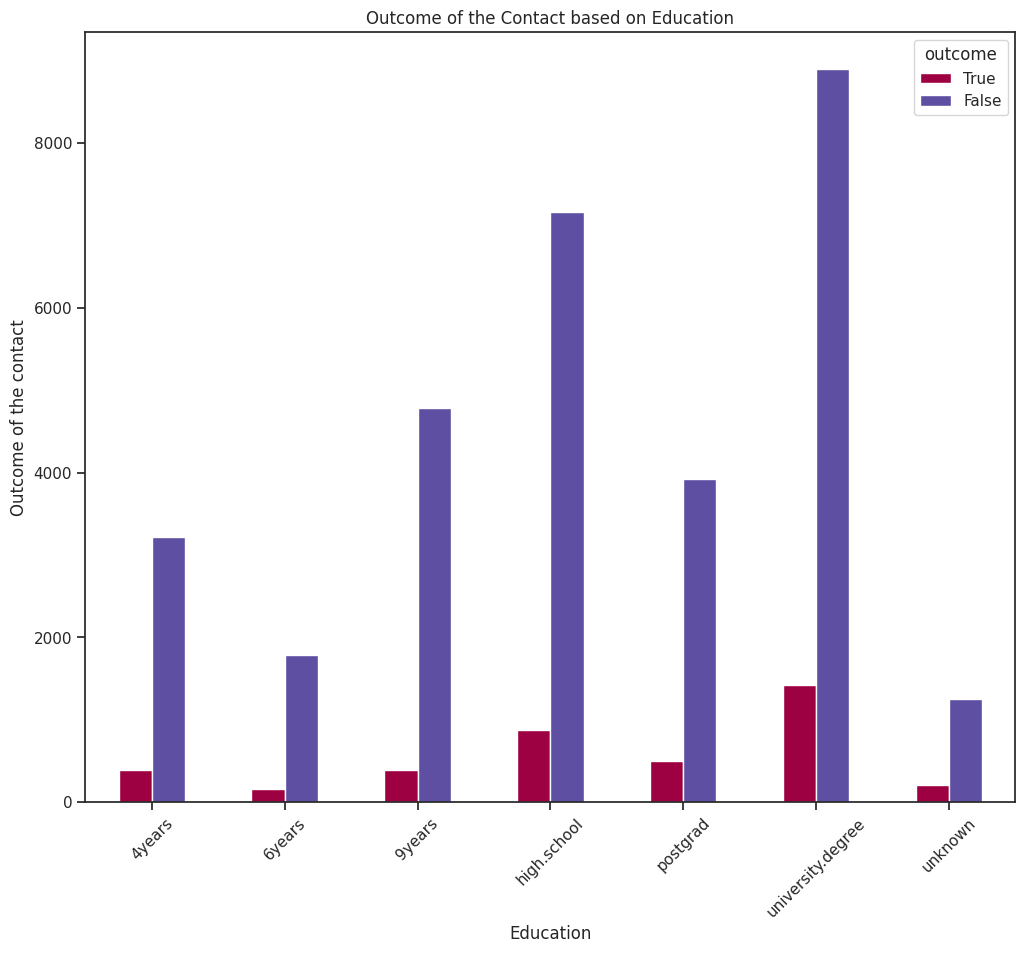

In [ ]:
df_education.plot(kind = "bar", rot = 45, figsize = (12, 10), colormap = "Spectral",
                  xlabel = "Education", ylabel = "Outcome of the contact",
                  title = "Outcome of the Contact based on Education");

In [ ]:
df_age = df_tr[df_tr["age"] < 70]                # The Number of Customers above 70 is small and can be omited
age_unique = df_age["age"].unique().tolist()
age_unique.sort()
#print(age_unique)

age_counts = df_age["age"].value_counts().sort_index()

In [ ]:
df_age_true = df_outcome_true[df_outcome_true["age"] < 70]                # The Number of Customers above 70 is small and can be omited
age_unique_true = df_age_true["age"].unique().tolist()
age_unique_true.sort()
#print(age_unique_true)

age_counts_true = df_age_true["age"].value_counts().sort_index()

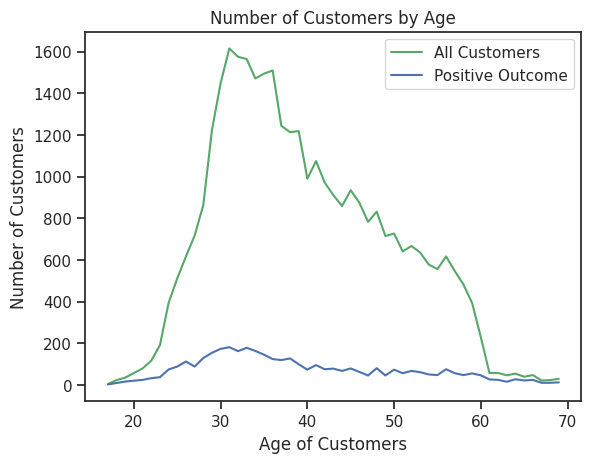

In [ ]:
plt.plot(age_unique, age_counts, "g")
plt.plot(age_unique_true, age_counts_true, "b")

plt.title("Number of Customers by Age")
plt.xlabel("Age of Customers")
plt.ylabel("Number of Customers")
plt.legend(["All Customers", "Positive Outcome"])
#plt.xticks(df_tr["month_no"].unique())
plt.show()

In [ ]:
labels = df_tr["marital"].unique()

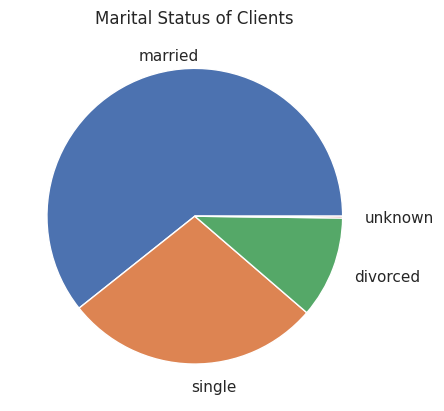

In [ ]:
df_tr["marital"].value_counts().plot(kind = "pie", ylabel = "", labels = labels,
                                     textprops = {"ha": "left", "va": "center"},
                                     labeldistance = 1.15, title = "Marital Status of Clients");

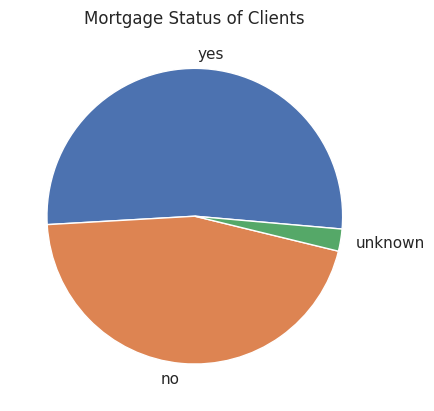

In [ ]:
df_tr["mortgage"].value_counts().plot(kind = "pie", startangle = -5, ylabel = "",
                                      title = "Mortgage Status of Clients");

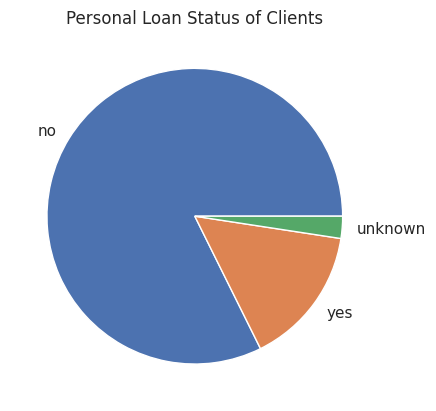

In [ ]:
df_tr["personal_loan"].value_counts().plot(kind = "pie", ylabel = "",
                                           title = "Personal Loan Status of Clients");

In [ ]:
clients_with_mortgage = len(df_outcome_true[df_outcome_true["mortgage"] == "yes"])
clients_with_loan = len(df_outcome_true[df_outcome_true["personal_loan"] == "yes"])
clients_true_total = len(df_outcome_true)

clients_with_mortgage, clients_with_loan, clients_true_total

(2133, 573, 3952)

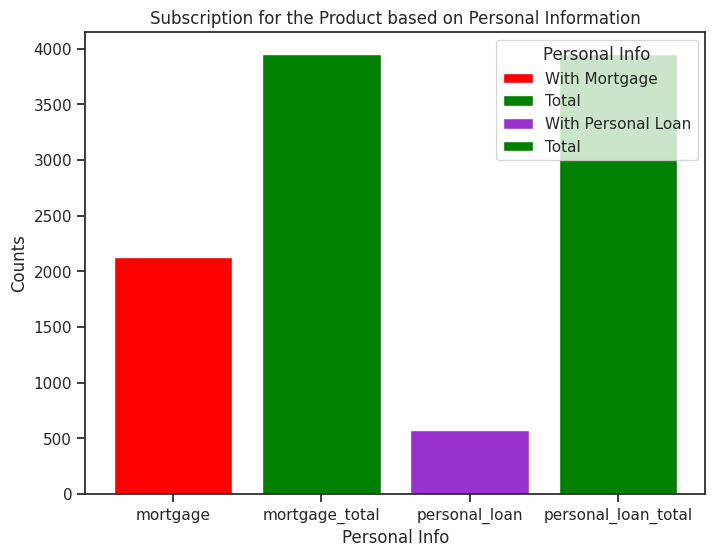

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6))

personal_info = ["mortgage", "mortgage_total", "personal_loan", "personal_loan_total"]
counts = [clients_with_mortgage, clients_true_total, clients_with_loan, clients_true_total]
bar_labels = ['With Mortgage', 'Total', 'With Personal Loan', 'Total']
bar_colors = ['red', 'green', 'darkorchid', 'green']

ax.bar(personal_info, counts, label = bar_labels, color = bar_colors)

ax.set_xlabel("Personal Info")
ax.set_ylabel("Counts")
ax.set_title("Subscription for the Product based on Personal Information")
ax.legend(title = 'Personal Info')

plt.show()

In [ ]:
marital_unknown = df_tr[df_tr["marital"] == "unknown"]
df_marital = df_tr.drop(index = marital_unknown.index)

In [ ]:
df_marital_pivot = df_marital.pivot_table(index = "marital",
                                          columns = "outcome",
                                          aggfunc = "size",
                                          sort = False)

In [ ]:
df_marital_pivot["Total"] = df_marital_pivot.iloc[:, 0] + df_marital_pivot.iloc[:, 1]

In [ ]:
df_marital_pivot

outcome,True,False,Total
marital,,,
married,2168,19072,21240
single,1378,8421,9799
divorced,395,3499,3894


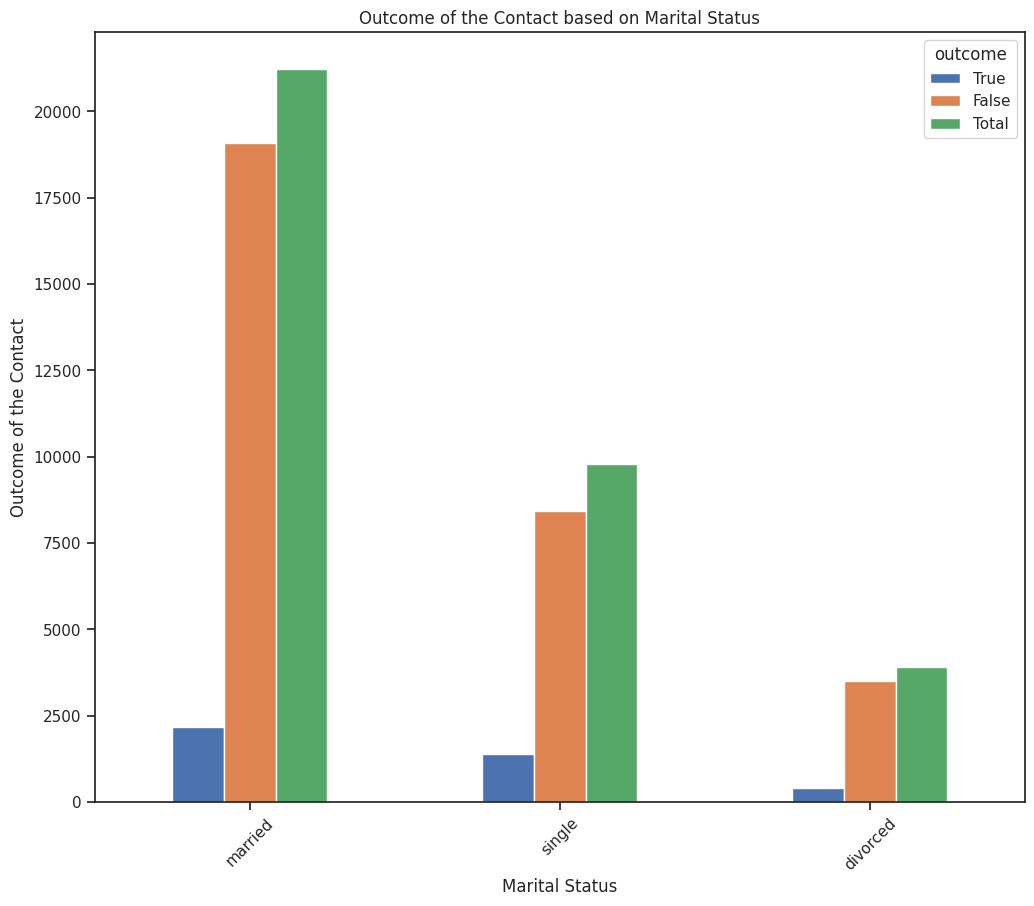

In [ ]:
df_marital_pivot.plot(kind = "bar", rot = 45, figsize = (12, 10),
                      xlabel = "Marital Status", ylabel = "Outcome of the Contact",
                      title = "Outcome of the Contact based on Marital Status");

#### Job of Customers 🛠️
> Most of the people with a classic savings account have an administrative or technical job. Let's set a 15% treshold for the success rate. The success rate is the ratio of the successful outcomes of a call and the total calls. People who have an administrative job are above the threshold. We could add to them the people who retired, unemployed people and people who participate in full-time education. The product is not so attractive to customers working in other areas. A survey should be made amongst the customers, in order to understand how to improve the product.

#### Type of Contact and Outcome of the Contact ☎️
> The relation between the type of contact and the positive outcome was analysed. Figures proved one more time the point that mobile calls lead to more subscriptions, compared to landline phones.

#### Personal Info of Customers Bonus Analysis 👦🏽
> Most of the customers have a high school education or a university degree. In addition, marketing was focused on people between the ages of 20 and 60. More than half of the people who subscribed for the product also have a mortgage (2133 out of 3952). On the other hand, only 573 out of 3952 have a personal loan in the bank. Lastly, a connection between the marital status and the positive outcome wasn't found





## 6. Analysis Based on the Jobs of the Customers

In [ ]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 15803 to 10936
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   contact_id             35000 non-null  Int64  
 1   month                  35000 non-null  string 
 2   month_no               35000 non-null  int64  
 3   day_of_week            35000 non-null  string 
 4   day_of_week_no         35000 non-null  int64  
 5   contact                35000 non-null  string 
 6   num_contacts           35000 non-null  Int64  
 7   days_since_previous    35000 non-null  Int64  
 8   num_contacts_previous  35000 non-null  Int64  
 9   outcome_previous       35000 non-null  string 
 10  age                    35000 non-null  Int64  
 11  marital                35000 non-null  string 
 12  job                    35000 non-null  string 
 13  education              35000 non-null  string 
 14  default                35000 non-null  string 
 15  mor

In [ ]:
#df_tr.groupby("outcome")[["num_contacts", "days_since_previous", "num_contacts_previous", "call_centre_volume"]].agg(["median", "min", "max"])

In [ ]:
df_outcome_true = df_tr[df_tr["outcome"] == "True"]
df_outcome_false = df_tr[df_tr["outcome"] == "False"]

In [ ]:
df_jobs_count = df["job"].value_counts()
df_outcome_true_jobs_count = df_outcome_true["job"].value_counts()
df_outcome_false_jobs_count = df_outcome_false["job"].value_counts()

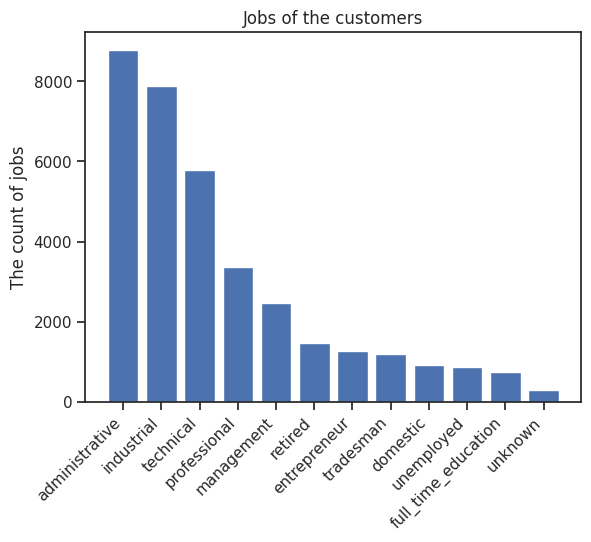

In [ ]:
plt.bar(df_jobs_count.index, df_jobs_count)
plt.title("Jobs of the customers")
plt.ylabel("The count of jobs")
plt.xticks(rotation = 45, ha = "right")
plt.show()

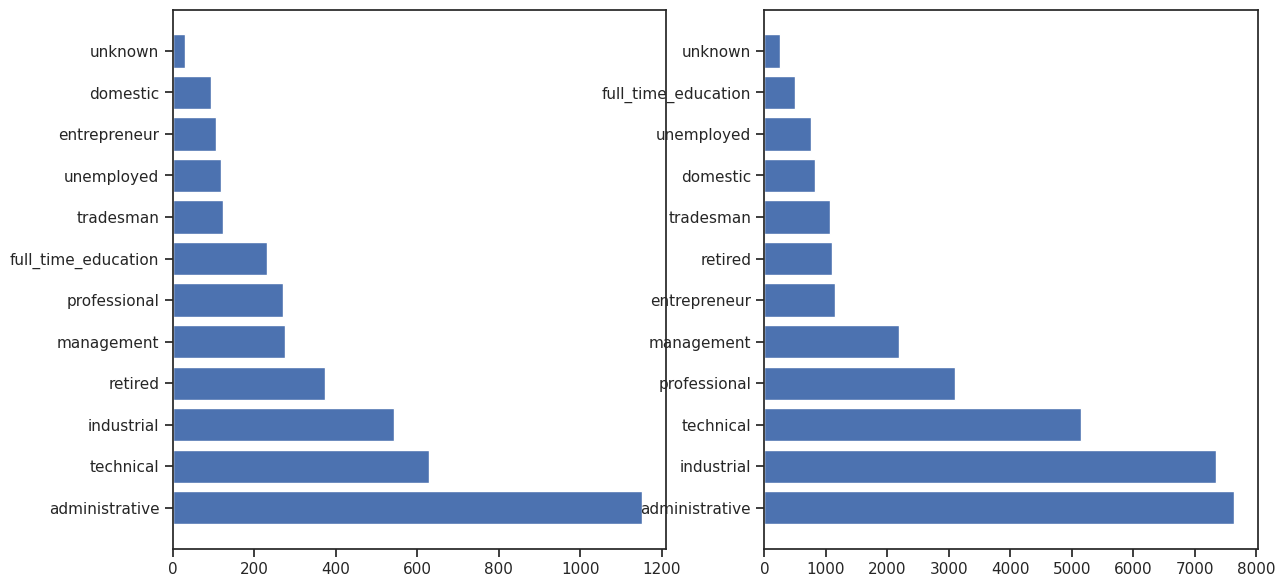

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (14, 7))

ax[0].barh(df_outcome_true_jobs_count.index, df_outcome_true_jobs_count)
ax[1].barh(df_outcome_false_jobs_count.index, df_outcome_false_jobs_count)

plt.show()

In [ ]:
df_outcome_true_pivot_fr = df_outcome_true.pivot_table(values = "forward_rate",
                                                       index = "job",
                                                       columns = "education",
                                                       aggfunc = "median")
df_outcome_true_pivot_fr.sample(10)

education,4years,6years,9years,high.school,none,postgrad,university.degree,unknown
job,,,,,,,,
unemployed,1.252,4.865,1.262,0.879,<NA>,0.859,0.8925,0.883
professional,4.961,1.3595,1.359,1.405,<NA>,1.263,0.9405,1.3335
entrepreneur,1.315,1.263,4.9085,4.4665,1.41,2.7015,1.405,1.291
administrative,0.77,3.3335,1.291,1.26,<NA>,1.252,1.259,0.8735
industrial,1.51,1.498,4.153,1.385,<NA>,1.262,1.3445,4.153
unknown,4.962,4.959,<NA>,2.7825,<NA>,<NA>,1.262,0.9
management,4.856,1.086,1.291,2.738,<NA>,1.4005,1.27,0.759
tradesman,4.968,4.86,4.9085,0.8285,4.076,1.266,1.2995,0.984
technical,1.035,4.857,1.32,4.0485,<NA>,1.2835,1.262,0.9725


In [ ]:
df_outcome_false_pivot = df_outcome_false.pivot_table(values = "forward_rate",
                                                      index = "job",
                                                      columns = "education",
                                                      aggfunc = "median")
df_outcome_false_pivot.sample(10)

education,4years,6years,9years,high.school,none,postgrad,university.degree,unknown
job,,,,,,,,
technical,4.857,4.857,4.857,4.96,<NA>,4.864,4.866,4.857
entrepreneur,4.8565,4.856,4.856,4.857,1.41,4.858,4.856,4.8565
unknown,4.8575,4.86,4.8585,4.86,<NA>,1.354,4.856,4.96
management,4.857,4.856,4.857,4.857,<NA>,4.153,4.856,4.857
professional,4.865,4.857,4.857,4.857,<NA>,4.857,4.172,4.858
full_time_education,1.687,1.266,1.266,1.27,<NA>,1.008,4.12,0.982
unemployed,4.8555,4.857,4.855,4.857,<NA>,4.856,4.858,4.86
retired,4.856,4.864,4.857,4.856,0.834,4.857,4.021,4.857
industrial,4.859,4.857,4.857,4.857,4.86,4.857,4.857,4.864


In [ ]:
df_outcome_true_pivot_fr = df_outcome_true.pivot_table(values = "forward_rate",
                                                       index = "job",
                                                       columns = "personal_loan",
                                                       aggfunc = "median")
df_outcome_true_pivot_fr.sample(10)

personal_loan,no,unknown,yes
job,,,
management,1.266,2.5145,4.021
technical,1.267,1.27,1.365
industrial,1.4745,1.466,3.5645
retired,0.8715,0.899,0.8515
unknown,1.262,<NA>,4.857
tradesman,1.286,0.896,1.385
entrepreneur,1.41,4.962,4.12
domestic,0.962,0.728,0.896
unemployed,0.88,1.531,0.9355


In [ ]:
df_outcome_false_pivot = df_outcome_false.pivot_table(values = "forward_rate",
                                                      index = "job",
                                                      columns = "education",
                                                      aggfunc = "median")